# Segmentação Híbrida — K-Means × Família de Produto × Frequência

Cruza a segmentação de clientes do `2.Kmeans.ipynb` (modelo atual: k=4, 5 features — volume, preço, margem, produtos e recência) com duas dimensões comerciais que o clustering não capturou diretamente: **qual família de produto o cliente compra** e **com que frequência**.

## Histórico

Este notebook foi originalmente construído sobre o Teste 5 (k=5, 6 features) e depois atualizado para o modelo atual (k=4, 5 features, sem `frequencia_mensal`). A versão original tinha problema de contagem (pedidos faturados em várias remessas/dias inflavam o número de transações); a versão corrigida (`frequencia_mensal_corrigida`, via `pedidos.csv`) foi depois testada por ablação como candidata a feature do K-Means (`2.Kmeans.ipynb`, seção 14) — melhora silhueta e Davies-Bouldin, mas dissolve o cluster Especial dentro do Pequeno (93,8% do Especial migra pra lá), então optamos por não incluí-la no treino. Como dimensão de enriquecimento (não como feature do clustering), usamos `frequencia_mensal_corrigida` (`1.EDA_Kmeans.ipynb`, seção 9.1) — conta pedidos únicos (`DOC_VENDA`) via `pedidos.csv` em vez de linhas de remessa da base de vendas, corrigindo a mesma inflação que tirou `frequencia_mensal` do modelo. Também trocamos `segmento_b2b` por `cnae_descricao` (cruzamento CNPJ → Receita Federal) como dimensão de enriquecimento de setor — mais granular e sem o "buraco negro" das categorias genéricas OUTROS/OUTRAS INDÚSTRIAS.

As correções abaixo foram feitas em relação ao pedido original (`teste_hibrido.txt`) e seguem válidas independente da versão do modelo K-Means:

1. **Atualização (supera a decisão original abaixo): usamos top 10 famílias por volume, sem bucket `Outras`.** O pedido original pedia famílias nomeadas cobrindo ~90% do volume; isso exigiria ~23 famílias (inviável), então a decisão original foi 8 famílias + `Outras` como resíduo (cobertura 100% por construção, não porque 100% fosse um objetivo). Essa lógica deixou de fazer sentido: agora usamos as **10** famílias de maior volume, sem bucket `Outras`, e reportamos a cobertura real de volume/receita em vez de forçar 100%. Isso vale tanto para as visões exploratórias (seção 8) quanto para a matriz cluster × família (seção 3) e o Pareto (seção 6).
2. **`tipo_movimento_eda` não estava salvo em nenhum cache** — é recalculado aqui a
   partir da mesma regra do `1.EDA_Kmeans.ipynb` (seção 2): venda = volume e receita líquida
   positivos.
3. **Metodologia de "família por cliente" explicitada** (o pedido original não detalhava): a matriz cluster × família usa as transações reais de cada família, restritas ao top 10 (um cliente pode contribuir para mais de uma coluna); já a **família principal** por cliente (usada em `segmentacao_completa.csv`) é o nome real da família de **maior volume** do cliente, sem restringir ao top 10 nem agrupar em bucket — todo cliente recebe o nome real da família que mais compra.
4. **Células pequenas são descartadas, não fundidas**: células (cluster × família do top 10) com menos de 10 clientes são simplesmente removidas da matriz, em vez de fundidas num bucket `Outras/Baixo volume` — consistente com aceitar cobertura parcial em vez de forçar 100%.
5. **Sem gráfico Sankey** — exigiria uma biblioteca (plotly) fora do ambiente atual;
   mantidos heatmap, bubble chart e Pareto, que cobrem a mesma leitura analítica.


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid', palette='deep')

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RAW_CACHE = ROOT / 'outputs' / 'cache' / 'base_Lubrax_origem.pkl'
SEGMENTACAO_PATH = ROOT / 'outputs' / '2. Clusterização' / 'segmentacao_clientes_kmeans.csv'
OUTPUT_DIR = ROOT / 'outputs' / '2. Clusterização' / '2.segmentacao_hibrida'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EPS = 1e-6
MIN_CLIENTES_CELULA = 10
TOP_N_FAMILIAS = 10

print(f"Diretório raiz: {ROOT}")
print(f"Saída será gravada em: {OUTPUT_DIR}")

Diretório raiz: C:\Volix\vibra-lubrax
Saída será gravada em: C:\Volix\vibra-lubrax\outputs\2. Clusterização\2.segmentacao_hibrida


## 1. Carregar segmentação K-Means (modelo atual) e classificar vendas

Reaproveita a segmentação já treinada (`segmentacao_clientes_kmeans.csv`, gerada pelo
`2.Kmeans.ipynb`) — não retreina o K-Means. Para a base transacional, aplica a mesma
regra de classificação do `1.EDA_Kmeans.ipynb`: uma linha é **venda** quando volume e receita
líquida são ambos positivos.

In [2]:
segmentacao = pd.read_csv(SEGMENTACAO_PATH)

# Nomes de negócio dos clusters (definidos no 2.Kmeans.ipynb a partir do perfil numérico)
NOMES_CLUSTER = {0: 'Pequeno', 1: 'Grande', 2: 'Especial', 3: 'Médio'}
segmentacao['cluster_nome'] = segmentacao['cluster'].map(NOMES_CLUSTER)

SIGLA_UF = {
    'Acre': 'AC', 'Alagoas': 'AL', 'Amapá': 'AP', 'Amazonas': 'AM', 'Bahia': 'BA', 'Ceará': 'CE',
    'Distrito Federal': 'DF', 'Brasília': 'DF', 'Espírito Santo': 'ES', 'Goiás': 'GO',
    'Maranhão': 'MA', 'Mato Grosso': 'MT', 'Mato Grosso do Sul': 'MS', 'Minas Gerais': 'MG',
    'Pará': 'PA', 'Paraíba': 'PB', 'Paraná': 'PR', 'Pernambuco': 'PE', 'Piauí': 'PI',
    'Rio de Janeiro': 'RJ', 'Rio Grande do Norte': 'RN', 'Rio Grande do Sul': 'RS',
    'Rondônia': 'RO', 'Roraima': 'RR', 'Santa Catarina': 'SC', 'São Paulo': 'SP',
    'Sergipe': 'SE', 'Tocantins': 'TO',
}

print(f"✓ Segmentação carregada: {len(segmentacao):,} clientes, {segmentacao['cluster'].nunique()} clusters")
display(segmentacao['cluster'].value_counts().sort_index())

✓ Segmentação carregada: 7,050 clientes, 4 clusters


cluster
0    4656
1     265
2     998
3    1131
Name: count, dtype: int64

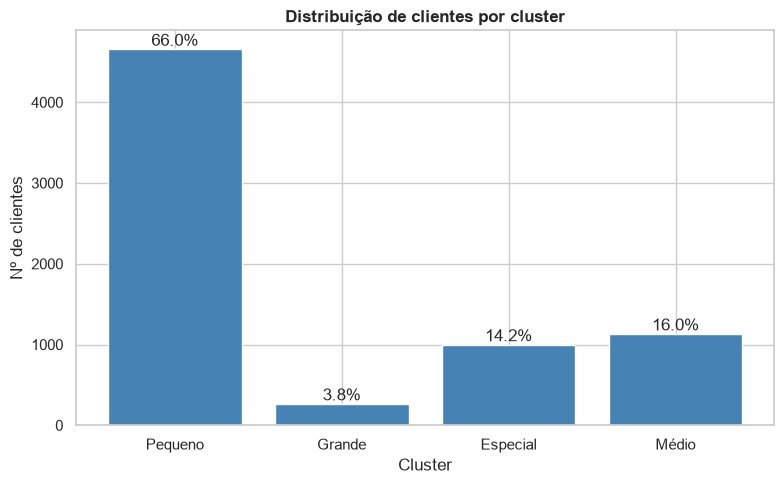

✓ distribuicao_clusters.png salvo


In [3]:
dist_clusters = segmentacao['cluster'].value_counts().sort_index()
pct_clusters = (dist_clusters / dist_clusters.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar([NOMES_CLUSTER[i] for i in dist_clusters.index], dist_clusters.values, color='steelblue')
for bar, pct in zip(bars, pct_clusters.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{pct}%', ha='center', va='bottom')
ax.set_xlabel('Cluster'); ax.set_ylabel('Nº de clientes')
ax.set_title('Distribuição de clientes por cluster', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'distribuicao_clusters.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ distribuicao_clusters.png salvo')


In [4]:
df_raw = pd.read_pickle(RAW_CACHE)
print(f"✓ Base transacional carregada: {len(df_raw):,} linhas × {df_raw.shape[1]} colunas")

volume = pd.to_numeric(df_raw['Volume'], errors='coerce')
receita_liquida = pd.to_numeric(df_raw['Receita líquida'], errors='coerce')
lucro_reposicao = pd.to_numeric(df_raw['LB Reposição'], errors='coerce')

venda = volume.gt(EPS) & receita_liquida.gt(EPS)
print(f"Vendas elegíveis (mesma regra do EDA): {venda.sum():,} de {len(df_raw):,} linhas ({venda.mean()*100:.1f}%)")

pricing = df_raw.loc[venda, ['Código Cliente', 'Prod - Família de Produtos', 'Prod - Embalagem']].copy()
pricing['volume'] = volume[venda]
pricing['receita_liquida'] = receita_liquida[venda]
pricing['lucro_reposicao'] = lucro_reposicao[venda]
print(f"✓ {len(pricing):,} linhas de venda prontas para análise")

# Exclusão da família AV (pedido do cliente, mesmo filtro do 1.EDA_Kmeans.ipynb / 2.Kmeans.ipynb)
n_antes_av = len(pricing)
pricing = pricing[pricing['Prod - Família de Produtos'] != 'AV'].copy()
print(f"Excluindo família AV: {n_antes_av:,} -> {len(pricing):,} linhas de venda")

✓ Base transacional carregada: 253,624 linhas × 110 colunas
Vendas elegíveis (mesma regra do EDA): 245,456 de 253,624 linhas (96.8%)
✓ 245,456 linhas de venda prontas para análise
Excluindo família AV: 245,456 -> 244,058 linhas de venda


In [5]:
# Cobertura: clientes do K-Means que aparecem nas vendas elegíveis
clientes_kmeans = set(segmentacao['Código Cliente'])
clientes_vendas = set(pricing['Código Cliente'])
cobertura = len(clientes_kmeans & clientes_vendas) / len(clientes_kmeans) * 100
print(f"Cobertura: {cobertura:.1f}% dos {len(clientes_kmeans):,} clientes segmentados têm vendas elegíveis na base")
if cobertura < 95:
    print("⚠ Cobertura abaixo de 95% — investigar clientes sem vendas elegíveis antes de prosseguir.")

Cobertura: 100.0% dos 7,050 clientes segmentados têm vendas elegíveis na base


## 2. Famílias de produto: top 8 + `Outras`

In [6]:
familias_volume = pricing.groupby('Prod - Família de Produtos', observed=True)['volume'].sum().sort_values(ascending=False)
familias_clientes = pricing.groupby('Prod - Família de Produtos', observed=True)['Código Cliente'].nunique()

top_familias = familias_volume.head(TOP_N_FAMILIAS)
cobertura_top = top_familias.sum() / familias_volume.sum() * 100

familias_principais = pd.DataFrame({
    'familia': top_familias.index,
    'volume_total': top_familias.values,
    'clientes_unicos': familias_clientes.reindex(top_familias.index).values,
})
familias_principais['pct_volume'] = (familias_principais['volume_total'] / familias_volume.sum() * 100).round(2)
familias_principais['pct_volume_acumulado'] = familias_principais['pct_volume'].cumsum().round(2)

print(f"Top {TOP_N_FAMILIAS} famílias cobrem {cobertura_top:.1f}% do volume total ({len(familias_volume)} famílias no total).")
print("Sem bucket 'Outras' -- as famílias fora do top N ficam fora das análises de cluster × família (cobertura parcial, de propósito).")
display(familias_principais)

familias_principais.to_csv(OUTPUT_DIR / 'familias_principais.csv', index=False, encoding='utf-8-sig')
print("✓ familias_principais.csv salvo")

TOP_FAMILIAS_SET = set(top_familias.index)
pricing['familia_top10'] = np.where(pricing['Prod - Família de Produtos'].isin(TOP_FAMILIAS_SET),
                                      pricing['Prod - Família de Produtos'], np.nan)


Top 10 famílias cobrem 69.6% do volume total (109 famílias no total).
Sem bucket 'Outras' -- as famílias fora do top N ficam fora das análises de cluster × família (cobertura parcial, de propósito).


,familia,volume_total,clientes_unicos,pct_volume,pct_volume_acumulado
0,TOP TURBO,27824.34,4633,27.94,27.94
1,HYDRA XP,13386.82,2791,13.44,41.38
2,HYDRA,4985.00,1628,5.01,46.39
3,TOP TURBO PRO,4738.12,1641,4.76,51.15
4,GEAR,4737.43,1373,4.76,55.91
5,GL 5,4610.97,2881,4.63,60.54
6,TRM 5,2851.85,1850,2.86,63.40
7,FLUIDO PARA RADIADOR,2148.53,1043,2.16,65.56
8,UTILE,2138.92,833,2.15,67.71
9,UNITRACTOR,1893.12,1254,1.90,69.61


✓ familias_principais.csv salvo


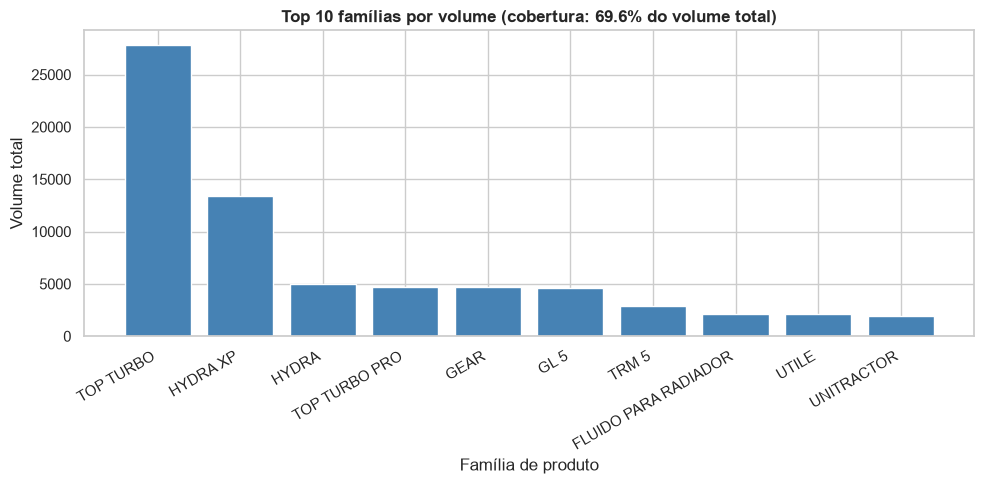

✓ top_familias.png salvo


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(familias_principais['familia'], familias_principais['volume_total'], color='steelblue')
ax.set_ylabel('Volume total'); ax.set_xlabel('Família de produto')
ax.set_title(f'Top {TOP_N_FAMILIAS} famílias por volume (cobertura: {cobertura_top:.1f}% do volume total)', fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top_familias.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ top_familias.png salvo')


## 3. Matriz Cluster × Família (3 × 9)

Cada linha de venda contribui para a célula (cluster do cliente, família da venda) —
um cliente que compra em mais de uma família aparece em mais de uma coluna. Preço e
margem são sempre ponderados (`soma(receita) / soma(volume)`), nunca médias de preços
por linha.

In [8]:
pricing_cluster = pricing.merge(segmentacao[['Código Cliente', 'cluster']], on='Código Cliente', how='inner')
print(f"✓ {len(pricing_cluster):,} linhas de venda com cluster atribuído")

pricing_cluster_top10 = pricing_cluster.dropna(subset=['familia_top10'])
matriz = pricing_cluster_top10.groupby(['cluster', 'familia_top10'], observed=True).agg(
    clientes_unicos=('Código Cliente', 'nunique'),
    volume_total=('volume', 'sum'),
    receita_liquida_total=('receita_liquida', 'sum'),
    lucro_reposicao_total=('lucro_reposicao', 'sum'),
).reset_index().rename(columns={'familia_top10': 'familia_bucket'})
matriz['preco_ponderado'] = matriz['receita_liquida_total'] / matriz['volume_total']
matriz['margem_pct_ponderada'] = matriz['lucro_reposicao_total'] / matriz['receita_liquida_total'] * 100
matriz['celula_pequena'] = matriz['clientes_unicos'] < MIN_CLIENTES_CELULA

print(f"Matriz (top {TOP_N_FAMILIAS} famílias, sem Outras): {len(matriz)} células "
      f"(de até {segmentacao['cluster'].nunique() * TOP_N_FAMILIAS} possíveis)")
print(f"Células com menos de {MIN_CLIENTES_CELULA} clientes: {matriz['celula_pequena'].sum()}")
display(matriz.sort_values(['cluster', 'volume_total'], ascending=[True, False]))

matriz.to_csv(OUTPUT_DIR / 'matriz_cluster_familia.csv', index=False, encoding='utf-8-sig')
print("✓ matriz_cluster_familia.csv salvo")


✓ 222,980 linhas de venda com cluster atribuído
Matriz (top 10 famílias, sem Outras): 40 células (de até 40 possíveis)
Células com menos de 10 clientes: 0


,cluster,familia_bucket,clientes_unicos,volume_total,receita_liquida_total,lucro_reposicao_total,preco_ponderado,margem_pct_ponderada,celula_pequena
5,0,TOP TURBO,2892,5502.23,6.365654e+07,9757129.28,11569.224800,15.327773,False
4,0,HYDRA XP,1541,1900.80,2.033035e+07,4040531.44,10695.678614,19.874386,False
3,0,HYDRA,937,921.46,9.340641e+06,1736195.22,10136.784006,18.587538,False
2,0,GL 5,1594,836.60,1.071415e+07,1687506.61,12806.774612,15.750265,False
6,0,TOP TURBO PRO,738,686.70,9.370699e+06,1278453.99,13645.986661,13.643102,False
1,0,GEAR,657,674.71,8.758281e+06,1752411.84,12980.807562,20.008628,False
9,0,UTILE,405,543.94,6.369756e+06,1262536.59,11710.401184,19.820801,False
7,0,TRM 5,881,424.45,6.017179e+06,868078.74,14176.415337,14.426672,False
8,0,UNITRACTOR,613,353.84,4.594383e+06,743570.41,12984.350950,16.184338,False
0,0,FLUIDO PARA RADIADOR,459,257.31,3.490211e+06,471316.47,13564.225992,13.503954,False


✓ matriz_cluster_familia.csv salvo


## 4. Células pequenas: descartadas, não fundidas

Diferente da versão anterior deste notebook (que fundia células com menos de 10 clientes num bucket `Outras/Baixo volume`), agora simplesmente **descartamos** essas células — consistente com a abordagem de top N famílias usada em todas as outras visões deste notebook: cobertura parcial é aceitável, não precisamos de um bucket "pega-tudo" para chegar a 100%.


In [9]:
n_pequenas = matriz['celula_pequena'].sum()
matriz_consolidada = matriz.loc[~matriz['celula_pequena']].drop(columns=['celula_pequena']).copy()
matriz_consolidada = matriz_consolidada.rename(columns={'familia_bucket': 'familia_final'})

print(f"Descartadas {n_pequenas} de {len(matriz)} células por terem menos de {MIN_CLIENTES_CELULA} clientes.")
print(f"Matriz final: {len(matriz_consolidada)} combinações viáveis (cluster × top {TOP_N_FAMILIAS} família).")
display(matriz_consolidada.sort_values(['cluster', 'volume_total'], ascending=[True, False]))

matriz_consolidada.to_csv(OUTPUT_DIR / 'matriz_cluster_familia_consolidada.csv', index=False, encoding='utf-8-sig')
print("✓ matriz_cluster_familia_consolidada.csv salvo")


Descartadas 0 de 40 células por terem menos de 10 clientes.
Matriz final: 40 combinações viáveis (cluster × top 10 família).


,cluster,familia_final,clientes_unicos,volume_total,receita_liquida_total,lucro_reposicao_total,preco_ponderado,margem_pct_ponderada
5,0,TOP TURBO,2892,5502.23,6.365654e+07,9757129.28,11569.224800,15.327773
4,0,HYDRA XP,1541,1900.80,2.033035e+07,4040531.44,10695.678614,19.874386
3,0,HYDRA,937,921.46,9.340641e+06,1736195.22,10136.784006,18.587538
2,0,GL 5,1594,836.60,1.071415e+07,1687506.61,12806.774612,15.750265
6,0,TOP TURBO PRO,738,686.70,9.370699e+06,1278453.99,13645.986661,13.643102
1,0,GEAR,657,674.71,8.758281e+06,1752411.84,12980.807562,20.008628
9,0,UTILE,405,543.94,6.369756e+06,1262536.59,11710.401184,19.820801
7,0,TRM 5,881,424.45,6.017179e+06,868078.74,14176.415337,14.426672
8,0,UNITRACTOR,613,353.84,4.594383e+06,743570.41,12984.350950,16.184338
0,0,FLUIDO PARA RADIADOR,459,257.31,3.490211e+06,471316.47,13564.225992,13.503954


✓ matriz_cluster_familia_consolidada.csv salvo


## 5. Dimensão frequência + segmentação final por cliente

Cada cliente recebe **uma família principal** (maior volume) e um **nível de
frequência** (`frequencia_mensal` já calculada no EDA: Ocasionais <1,5/mês, Regulares
1,5–3,5/mês, Frequentes >3,5/mês). Isso gera a tabela cliente → cluster → família →
frequência, usada na matriz consolidada e nas análises seguintes.

In [10]:
EDA_CACHE = ROOT / 'outputs' / '1. EDA' / 'kmeans_clientes_features.pkl'
customer_features_full = pd.read_pickle(EDA_CACHE)

# frequencia_mensal_corrigida usa pedidos únicos (DOC_VENDA) via pedidos.csv, não linhas de
# remessa da base de vendas -- evita a inflação por pedidos fraturados em várias remessas
# (ver 1.EDA_Kmeans.ipynb, seção 9.1).
freq_map = customer_features_full.set_index('Código Cliente')['frequencia_mensal_corrigida']
segmentacao['frequencia_mensal'] = segmentacao['Código Cliente'].map(freq_map)
segmentacao['nivel_frequencia'] = pd.cut(
    segmentacao['frequencia_mensal'], bins=[-np.inf, 1.5, 3.5, np.inf],
    labels=['Ocasionais', 'Regulares', 'Frequentes']
)
# Nível de margem -- tercis calculados na população do modelo (7.050 clientes), cortes
# arredondados para números redondos e fáceis de comunicar (13% e 18%).
segmentacao['nivel_margem'] = pd.cut(
    segmentacao['margem_pct_ponderada'], bins=[-np.inf, 0.13, 0.18, np.inf],
    labels=['Baixa', 'Média', 'Alta'])

print("Distribuição de níveis de frequência:")
display(segmentacao['nivel_frequencia'].value_counts())
print((segmentacao['nivel_frequencia'].value_counts(normalize=True) * 100).round(1))

# CNAE completo (código + divisão simplificada) -- ver 1.EDA_Kmeans.ipynb, seção 9.2/9.3
cnae_map = customer_features_full.set_index('Código Cliente')['cnae_codigo']
divisao_nome_map = customer_features_full.set_index('Código Cliente')['cnae_divisao_nome']
segmentacao['cnae_codigo'] = segmentacao['Código Cliente'].map(cnae_map)
segmentacao['cnae_divisao_nome'] = segmentacao['Código Cliente'].map(divisao_nome_map)

# UF do cliente -- ver 1.EDA_Kmeans.ipynb, seção 9.4
estado_map = customer_features_full.set_index('Código Cliente')['estado_cliente']
segmentacao['estado_cliente'] = segmentacao['Código Cliente'].map(estado_map)

# Frete por m³ -- testado como feature do K-Means e descartado por ablação
# (2.Kmeans.ipynb, seção 13); mantido como enriquecimento.
frete_map = customer_features_full.set_index('Código Cliente')['frete_por_m3']
segmentacao['frete_por_m3'] = segmentacao['Código Cliente'].map(frete_map)

Distribuição de níveis de frequência:


nivel_frequencia
Ocasionais    4812
Regulares     1876
Frequentes     362
Name: count, dtype: int64

nivel_frequencia
Ocasionais    68.3
Regulares     26.6
Frequentes     5.1
Name: proportion, dtype: float64


### 5.1 Nível de frequência e CNAE por cluster

`nivel_frequencia` (corrigida) e `cnae_descricao` já vêm em `segmentacao` (exportadas pelo
`2.Kmeans.ipynb`) — aqui olhamos a distribuição de cada uma **por cluster**, não só no
agregado da base inteira.


In [11]:
print("Nível de frequência por cluster (%):")
display((pd.crosstab(segmentacao['cluster'], segmentacao['nivel_frequencia'], normalize='index') * 100).round(1))


Nível de frequência por cluster (%):


nivel_frequencia,Ocasionais,Regulares,Frequentes
cluster,,,
0,76.9,19.7,3.5
1,17.4,61.5,21.1
2,73.8,22.3,3.8
3,39.7,50.8,9.5


### Nível de margem por cluster

Classificamos `margem_pct_ponderada` em 3 faixas (tercis da população do modelo, cortes arredondados): **Baixa** (< 13%), **Média** (13%–18%) e **Alta** (≥ 18%). Cada faixa fica com aproximadamente 1/3 da base (32,5% / 35,6% / 31,9%).


Nível de margem por cluster (%):


nivel_margem,Baixa,Média,Alta
cluster,,,
0,29.3,36.5,34.3
1,35.1,37.4,27.5
2,48.5,28.1,23.4
3,31.1,38.5,30.4


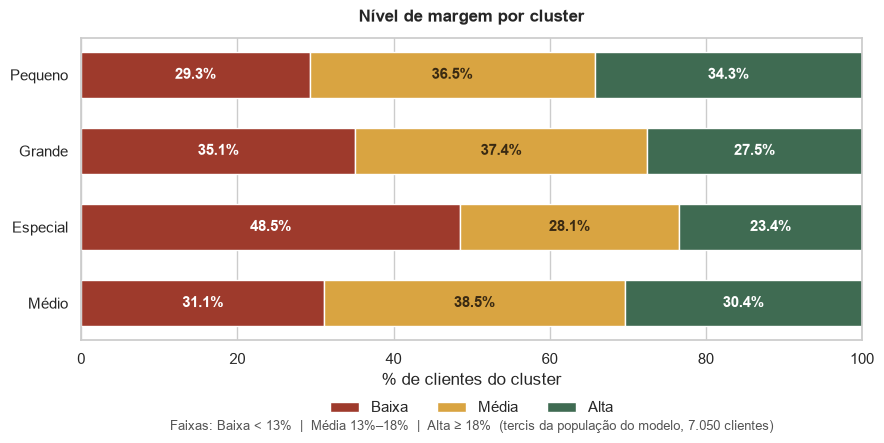

✓ nivel_margem_por_cluster.png salvo


In [12]:
print("Nível de margem por cluster (%):")
display((pd.crosstab(segmentacao['cluster'], segmentacao['nivel_margem'], normalize='index') * 100).round(1))

pivot_margem_nivel = pd.crosstab(segmentacao['cluster'], segmentacao['nivel_margem'], normalize='index') * 100
pivot_margem_nivel = pivot_margem_nivel[['Baixa', 'Média', 'Alta']]
rotulos_margem_cluster = [NOMES_CLUSTER[c] for c in pivot_margem_nivel.index]

cores_margem = {'Baixa': '#9E3A2C', 'Média': '#D9A441', 'Alta': '#3F6B52'}

fig, ax = plt.subplots(figsize=(9, 4.8))
esquerda = np.zeros(len(pivot_margem_nivel))
for nivel in ['Baixa', 'Média', 'Alta']:
    valores = pivot_margem_nivel[nivel].values
    bars = ax.barh(rotulos_margem_cluster, valores, left=esquerda, color=cores_margem[nivel],
                    label=nivel, height=0.6)
    for bar, v in zip(bars, valores):
        if v >= 4:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
                     f'{v:.1f}%', ha='center', va='center', fontsize=10.5, fontweight='bold',
                     color='white' if nivel != 'Média' else '#3a2a12')
    esquerda += valores

ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel('% de clientes do cluster')
ax.set_title('Nível de margem por cluster', fontweight='bold', pad=12)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.16), ncol=3, frameon=False, fontsize=10.5)
ax.text(0.5, -0.30, 'Faixas: Baixa < 13%  |  Média 13%\u201318%  |  Alta \u2265 18%  '
        '(tercis da população do modelo, 7.050 clientes)',
        transform=ax.transAxes, ha='center', fontsize=9.5, color='#555555')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'nivel_margem_por_cluster.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ nivel_margem_por_cluster.png salvo')


### Cluster Especial, margem Baixa: quem são esses clientes?

998 clientes formam o cluster Especial; 484 (48,5%) caem na faixa de margem **Baixa**. Onde esses clientes estão concentrados?


In [13]:
especial_id = [k for k, v in NOMES_CLUSTER.items() if v == 'Especial'][0]
clientes_especial_todos = set(segmentacao.loc[segmentacao['cluster'] == especial_id, 'Código Cliente'])
clientes_especial_baixa = set(segmentacao.loc[
    (segmentacao['cluster'] == especial_id) & (segmentacao['nivel_margem'] == 'Baixa'), 'Código Cliente'])
print(f"Cluster Especial: {len(clientes_especial_todos):,} clientes | "
      f"{len(clientes_especial_baixa):,} ({len(clientes_especial_baixa) / len(clientes_especial_todos) * 100:.1f}%) "
      "na faixa de margem Baixa")


Cluster Especial: 998 clientes | 484 (48.5%) na faixa de margem Baixa


In [14]:
especial_df = segmentacao[segmentacao['cluster'] == especial_id]
mtms_no_especial = especial_df['estado_cliente'].isin(['Mato Grosso', 'Mato Grosso do Sul'])

print("Nível de margem dentro do Especial, MT/MS vs. resto:")
display((especial_df.groupby(mtms_no_especial)['nivel_margem']
         .value_counts(normalize=True).unstack()[['Baixa', 'Média', 'Alta']] * 100).round(1))

print("\nFrete médio (R$/m³) por nível de margem, dentro do Especial:")
display(especial_df.groupby('nivel_margem')['frete_por_m3'].mean().round(1))


Nível de margem dentro do Especial, MT/MS vs. resto:


nivel_margem,Baixa,Média,Alta
estado_cliente,,,
False,46.8,28.1,25.1
True,57.7,27.6,14.7



Frete médio (R$/m³) por nível de margem, dentro do Especial:


nivel_margem
Baixa    655.3
Média    572.1
Alta     558.2
Name: frete_por_m3, dtype: float64

**Achado 2 — a pista de frete se confirma aqui também:** dentro do Especial, clientes de Mato Grosso/MS estão mais concentrados na faixa de margem Baixa (57,7% deles, contra 46,8% do resto do grupo) — e o frete médio já é o mais alto justamente na faixa Baixa (R$ 655/m³, contra R$ 558/m³ na faixa Alta). Junta-se ao achado de preço (seção acima) e ao de frete (mais adiante): o custo logístico parece corroer margem de forma transversal a produtos, concentrado em clientes de regiões mais distantes — reforça que vale investigar com o time de logística/pricing antes de tratar isso como desconto comercial mal aplicado.


In [15]:
print("Top 5 divisões de CNAE por cluster (% de clientes) -- versão simplificada, sem\n      subclasses repetidas (ex.: \"transporte rodoviário de carga\" e \"...de passageiros\"\n      viram uma só divisão, \"Transporte terrestre\"):\n")
for c in sorted(segmentacao['cluster'].unique()):
    sub = segmentacao.loc[segmentacao['cluster'] == c, 'cnae_divisao_nome']
    dist = sub.value_counts(normalize=True).head(5) * 100
    print(f"Cluster {c} ({len(sub):,} clientes):")
    for cnae, pct in dist.items():
        print(f"  {cnae}: {pct:.1f}%")
    print()


Top 5 divisões de CNAE por cluster (% de clientes) -- versão simplificada, sem
      subclasses repetidas (ex.: "transporte rodoviário de carga" e "...de passageiros"
      viram uma só divisão, "Transporte terrestre"):

Cluster 0 (4,656 clientes):
  Transporte terrestre: 34.3%
  Obras de infraestrutura: 7.6%
  Aluguel de máquinas e equipamentos: 5.6%
  Comércio por atacado: 4.7%
  Produtos de minerais não-metálicos: 4.2%

Cluster 1 (265 clientes):
  Transporte terrestre: 40.5%
  Extração de minerais não-metálicos: 7.6%
  Obras de infraestrutura: 6.4%
  Produtos de minerais não-metálicos: 4.9%
  Aluguel de máquinas e equipamentos: 4.9%

Cluster 2 (998 clientes):
  Transporte terrestre: 43.2%
  Obras de infraestrutura: 6.6%
  Extração de minerais não-metálicos: 5.5%
  Aluguel de máquinas e equipamentos: 5.0%
  Produtos de minerais não-metálicos: 4.9%

Cluster 3 (1,131 clientes):
  Transporte terrestre: 39.0%
  Extração de minerais não-metálicos: 8.9%
  Aluguel de máquinas e equipamentos

### 5.0 Divisões de CNAE na base toda (antes de olhar por cluster)

Antes de cruzar CNAE com cluster, como fica a composição da base inteira? Cada divisão (2 primeiros dígitos do código CNAE) agrupa várias subclasses parecidas — ex.: "transporte rodoviário de carga" (4930-2/02), "...coletivo de passageiros" (4922-1/01) e "...de produtos perigosos" (4930-2/01) são subclasses diferentes, mas todas caem na mesma divisão **49 — Transporte terrestre** (`1.EDA_Kmeans.ipynb`, seção 9.3). O código completo (7 dígitos) continua disponível em `cnae_codigo` para quem precisar do detalhe fino.


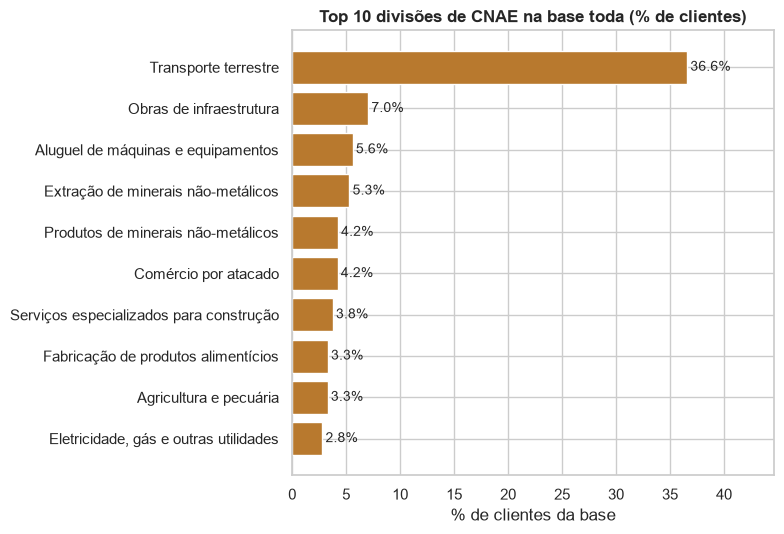

✓ cnae_divisao_base_geral.png salvo


In [16]:
def truncar(texto, n=42):
    texto = str(texto)
    return texto if len(texto) <= n else texto[:n - 1] + '…'

dist_cnae_geral = segmentacao['cnae_divisao_nome'].value_counts(normalize=True).head(10) * 100
rotulos_geral = [truncar(i) for i in dist_cnae_geral.index]

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.barh(rotulos_geral[::-1], dist_cnae_geral.values[::-1], color='#B8792E')
for bar, v in zip(bars, dist_cnae_geral.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2, f'{v:.1f}%',
            va='center', fontsize=10)
ax.set_xlabel('% de clientes da base'); ax.set_ylabel('')
ax.set_title('Top 10 divisões de CNAE na base toda (% de clientes)', fontweight='bold')
ax.set_xlim(0, dist_cnae_geral.max() * 1.22)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cnae_divisao_base_geral.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ cnae_divisao_base_geral.png salvo')


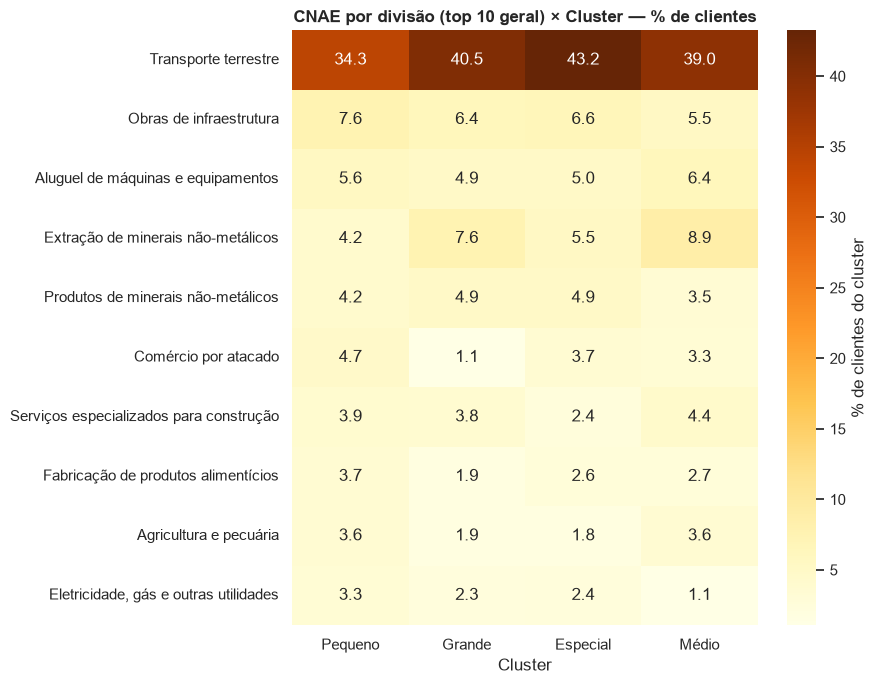

✓ cnae_por_cluster.png salvo


In [17]:
def truncar(texto, n=42):
    texto = str(texto)
    return texto if len(texto) <= n else texto[:n - 1] + '…'

top_cnaes_geral = segmentacao['cnae_divisao_nome'].value_counts().head(10).index
pivot_cnae = pd.crosstab(segmentacao['cluster'], segmentacao['cnae_divisao_nome'], normalize='index') * 100
pivot_cnae = pivot_cnae[top_cnaes_geral].T
pivot_cnae.index = [truncar(i) for i in pivot_cnae.index]
rotulos_cnae_cluster = [NOMES_CLUSTER[c] for c in pivot_cnae.columns]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(pivot_cnae, annot=True, fmt='.1f', cmap='YlOrBr', ax=ax,
            xticklabels=rotulos_cnae_cluster, cbar_kws={'label': '% de clientes do cluster'})
ax.set_xticklabels(rotulos_cnae_cluster, rotation=0)
ax.set_title('CNAE por divisão (top 10 geral) × Cluster — % de clientes', fontweight='bold')
ax.set_xlabel('Cluster'); ax.set_ylabel('')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cnae_por_cluster.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ cnae_por_cluster.png salvo")


### 5.2 % de clientes AGRO (CNAE) — preparação para análise de safra

`segmento_b2b` tagueava só 3,90% da base como AGRONEGOCIO — mas esse rótulo mistura agricultura de verdade (soja, café, laranja...) com pecuária, pesca, madeira e até transporte ligado ao agro. Usamos o CNAE (seção A oficial — divisões 01 agricultura/pecuária, 02 produção florestal, 03 pesca/aquicultura) para isolar quem é agro de verdade, cliente a cliente — base para o próximo passo: cruzar cada CNAE de cultivo com o calendário de safra da cultura (soja, café, laranja etc. têm janelas de colheita bem diferentes) e testar se isso vira uma feature de sazonalidade específica para esse recorte, em vez de uma sazonalidade genérica (que já testamos e descartamos por falta de cobertura para o resto da base).


In [18]:
segmentacao['cnae_secao_agro'] = segmentacao['cnae_codigo'].astype('string').str[:2].isin(['01', '02', '03'])

pct_agro_total = segmentacao['cnae_secao_agro'].mean() * 100
print(f"% de clientes AGRO (CNAE seção A, base toda): {pct_agro_total:.2f}% "
      f"({segmentacao['cnae_secao_agro'].sum():,} de {len(segmentacao):,} clientes)\n")

print("% de clientes AGRO por cluster:")
display((segmentacao.groupby('cluster')['cnae_secao_agro'].mean() * 100).round(2))

print("\nDivisão CNAE dos clientes AGRO (01=agricultura/pecuária, 02=floresta, 03=pesca):")
display(segmentacao.loc[segmentacao['cnae_secao_agro'], 'cnae_codigo'].astype('string').str[:2].value_counts())


% de clientes AGRO (CNAE seção A, base toda): 4.18% (295 de 7,050 clientes)

% de clientes AGRO por cluster:


cluster
0    4.40
1    3.02
2    2.81
3    4.77
Name: cnae_secao_agro, dtype: float64


Divisão CNAE dos clientes AGRO (01=agricultura/pecuária, 02=floresta, 03=pesca):


cnae_codigo
01    224
02     60
03     11
Name: count, dtype: Int64

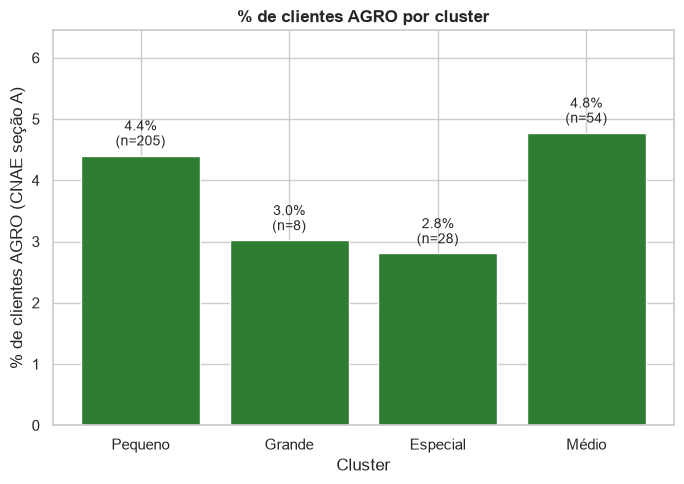

✓ agro_por_cluster.png salvo


In [19]:
agro_por_cluster = segmentacao.groupby('cluster')['cnae_secao_agro'].agg(['mean', 'sum'])
agro_por_cluster['pct'] = agro_por_cluster['mean'] * 100

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar([NOMES_CLUSTER[i] for i in agro_por_cluster.index], agro_por_cluster['pct'], color='#2E7D32')
for bar, (_, row) in zip(bars, agro_por_cluster.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f"{row['pct']:.1f}%\n(n={int(row['sum'])})", ha='center', va='bottom', fontsize=10)
ax.set_xlabel('Cluster'); ax.set_ylabel('% de clientes AGRO (CNAE seção A)')
ax.set_title('% de clientes AGRO por cluster', fontweight='bold')
ax.set_ylim(0, agro_por_cluster['pct'].max() * 1.35)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'agro_por_cluster.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ agro_por_cluster.png salvo")


### 5.2.1 O que os clientes AGRO compram, por cluster

Os clientes AGRO não são um bloco único — estão espalhados nos 4 clusters (seção 5.2), cada
um com um perfil de compra diferente. Aqui olhamos a família de produto que eles realmente
compram, dentro de cada cluster (% do volume AGRO daquele cluster).


295 clientes AGRO | 295 com vendas elegíveis na base (sem AV)
Cobertura do top 10 sobre o volume AGRO de cada cluster:


cluster
0    76.1
1    69.4
2    68.1
3    80.3
Name: volume, dtype: float64

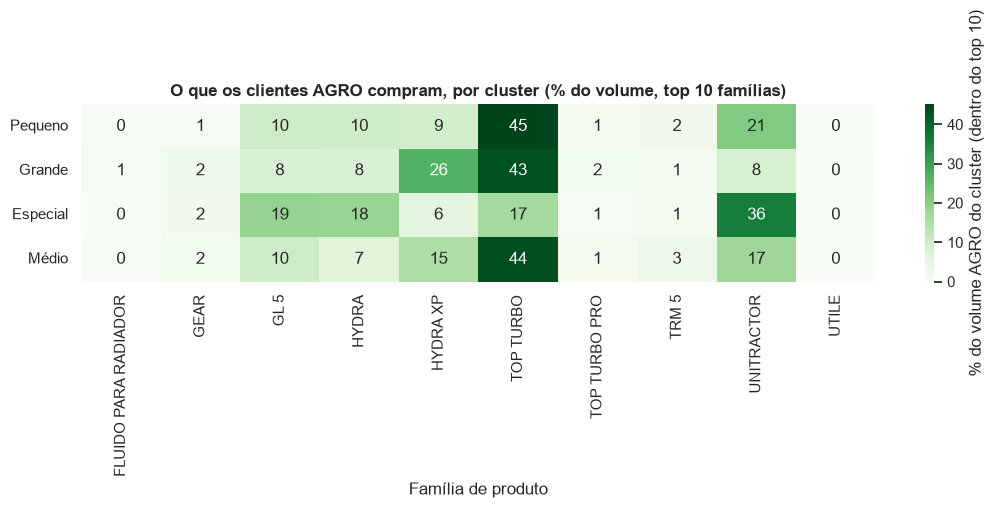

✓ produtos_agro_por_cluster.png salvo


In [20]:
clientes_agro = set(segmentacao.loc[segmentacao['cnae_secao_agro'], 'Código Cliente'])
pricing_agro = pricing_cluster[pricing_cluster['Código Cliente'].isin(clientes_agro)]
print(f"{len(clientes_agro):,} clientes AGRO | {pricing_agro['Código Cliente'].nunique():,} "
      f"com vendas elegíveis na base (sem AV)")

pricing_agro_top10 = pricing_agro.dropna(subset=['familia_top10'])
vol_agro_cluster_familia = pricing_agro_top10.groupby(['cluster', 'familia_top10'], observed=True)['volume'].sum()
cobertura_agro = (vol_agro_cluster_familia.groupby(level=0).sum() /
                  pricing_agro.groupby('cluster')['volume'].sum() * 100)
pivot_agro_produtos = (vol_agro_cluster_familia
    .groupby(level=0, group_keys=False).apply(lambda s: s / s.sum() * 100)
    .unstack(fill_value=0))
rotulos_agro = [NOMES_CLUSTER[i] for i in pivot_agro_produtos.index]

print(f"Cobertura do top {TOP_N_FAMILIAS} sobre o volume AGRO de cada cluster:")
display(cobertura_agro.round(1))

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.heatmap(pivot_agro_produtos, annot=True, fmt='.0f', cmap='Greens', ax=ax,
            yticklabels=rotulos_agro, cbar_kws={'label': '% do volume AGRO do cluster (dentro do top 10)'})
ax.set_yticklabels(rotulos_agro, rotation=0, va='center')
ax.set_title(f'O que os clientes AGRO compram, por cluster (% do volume, top {TOP_N_FAMILIAS} famílias)', fontweight='bold')
ax.set_xlabel('Família de produto'); ax.set_ylabel('')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'produtos_agro_por_cluster.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ produtos_agro_por_cluster.png salvo')


### 5.3 Maiores segmentos de CNAE por receita (não só por nº de clientes)

As visões acima (top 5, heatmap) são por **contagem de clientes** — um CNAE pode ter poucos
clientes mas concentrar muita receita, ou o oposto. Olhando por receita, cluster a cluster:


In [21]:
receita_cnae_cluster = segmentacao.groupby(['cluster', 'cnae_divisao_nome'])['receita_liquida_total'].sum()

for c in sorted(segmentacao['cluster'].unique()):
    sub = receita_cnae_cluster.loc[c].sort_values(ascending=False)
    receita_total_cluster = sub.sum()
    top5 = sub.head(5)
    print(f"Cluster {c} — receita total: R$ {receita_total_cluster:,.0f}")
    for cnae, receita in top5.items():
        print(f"  {cnae[:55]:55s} R$ {receita:>14,.0f}  ({receita / receita_total_cluster * 100:5.1f}%)")
    print()


Cluster 0 — receita total: R$ 198,131,213
  Transporte terrestre                                    R$     77,611,944  ( 39.2%)
  Obras de infraestrutura                                 R$     12,106,233  (  6.1%)
  Aluguel de máquinas e equipamentos                      R$     10,200,418  (  5.1%)
  Extração de minerais não-metálicos                      R$      9,217,502  (  4.7%)
  Produtos de minerais não-metálicos                      R$      8,850,961  (  4.5%)

Cluster 1 — receita total: R$ 288,274,480
  Transporte terrestre                                    R$    120,227,508  ( 41.7%)
  Extração de minerais não-metálicos                      R$     22,251,204  (  7.7%)
  Obras de infraestrutura                                 R$     16,209,702  (  5.6%)
  Produtos de minerais não-metálicos                      R$     13,833,095  (  4.8%)
  Serviços especializados para construção                 R$     12,820,134  (  4.4%)

Cluster 2 — receita total: R$ 52,407,731
  Transporte 

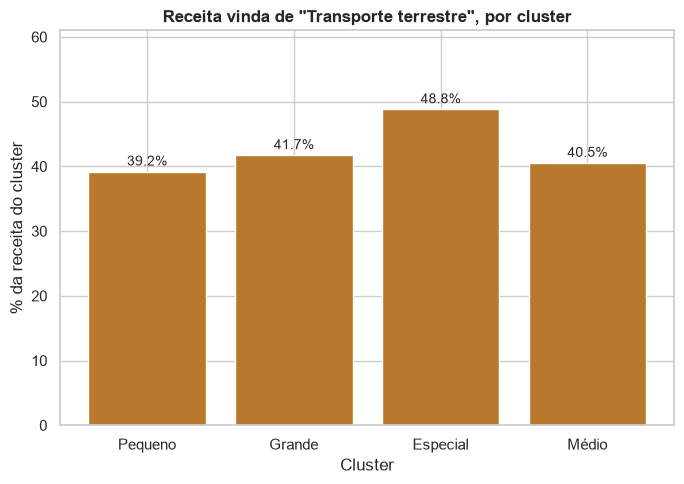

✓ receita_transporte_por_cluster.png salvo


In [22]:
pct_transporte_por_cluster = {}
for c in sorted(segmentacao['cluster'].unique()):
    sub = receita_cnae_cluster.loc[c]
    pct_transporte_por_cluster[c] = sub.get('Transporte terrestre', 0) / sub.sum() * 100
pct_transporte_por_cluster = pd.Series(pct_transporte_por_cluster)
rotulos_receita = [NOMES_CLUSTER[i] for i in pct_transporte_por_cluster.index]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(rotulos_receita, pct_transporte_por_cluster.values, color='#B8792E')
for bar, v in zip(bars, pct_transporte_por_cluster.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=10)
ax.set_xlabel('Cluster'); ax.set_ylabel('% da receita do cluster')
ax.set_title('Receita vinda de "Transporte terrestre", por cluster', fontweight='bold')
ax.set_ylim(0, pct_transporte_por_cluster.max() * 1.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'receita_transporte_por_cluster.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ receita_transporte_por_cluster.png salvo')


### 5.5 UF do cliente por cluster — o Especial está concentrado nalguma região?

O grupo Especial paga mais por m³ em praticamente toda família (seção 8). Antes de assumir que é um problema de política comercial, vale checar se é geografia — frete mais caro pra determinadas UFs explicaria parte do preço mais alto.


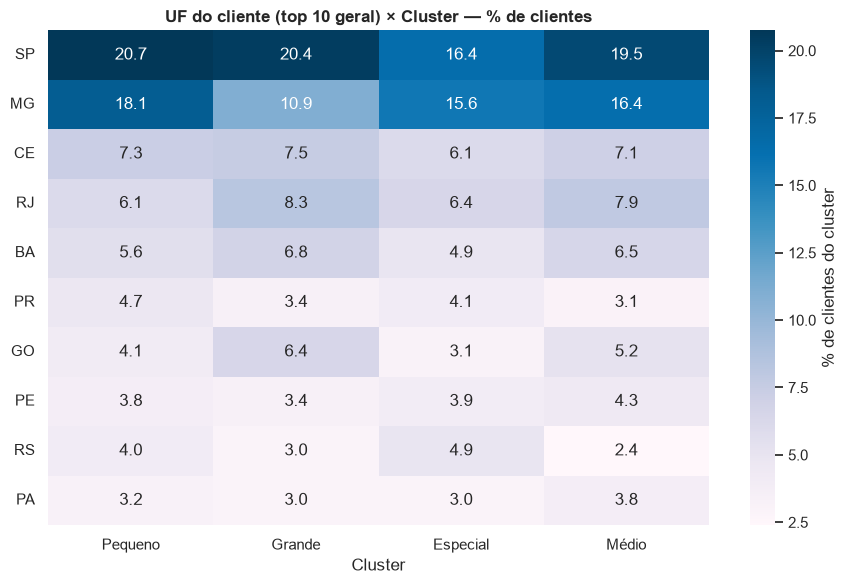

✓ uf_por_cluster.png salvo

UFs mais sobrerrepresentadas no cluster Especial vs. a base toda (razão >= 1.5x, min 10 clientes no Especial):
  Mato Grosso           11.2% do Especial vs.   2.6% da base toda (4.4x mais representado, n=112)
  Mato Grosso do Sul     4.4% do Especial vs.   1.6% da base toda (2.7x mais representado, n=44)
  Sergipe                1.4% do Especial vs.   0.8% da base toda (1.7x mais representado, n=14)


In [23]:
top_ufs_geral = segmentacao['estado_cliente'].value_counts().head(10).index
pivot_uf = pd.crosstab(segmentacao['cluster'], segmentacao['estado_cliente'], normalize='index') * 100
pivot_uf = pivot_uf[top_ufs_geral].T
rotulos_uf_cluster = [NOMES_CLUSTER[c] for c in pivot_uf.columns]

rotulos_uf_sigla = [SIGLA_UF.get(uf, uf) for uf in pivot_uf.index]
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(pivot_uf, annot=True, fmt='.1f', cmap='PuBu', ax=ax,
            xticklabels=rotulos_uf_cluster, yticklabels=rotulos_uf_sigla,
            cbar_kws={'label': '% de clientes do cluster'})
ax.set_xticklabels(rotulos_uf_cluster, rotation=0)
ax.set_yticklabels(rotulos_uf_sigla, rotation=0, va='center')
ax.set_title('UF do cliente (top 10 geral) × Cluster — % de clientes', fontweight='bold')
ax.set_xlabel('Cluster'); ax.set_ylabel('')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'uf_por_cluster.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ uf_por_cluster.png salvo')

especial_id = [k for k, v in NOMES_CLUSTER.items() if v == 'Especial'][0]
dist_especial = segmentacao.loc[segmentacao['cluster'] == especial_id, 'estado_cliente'].value_counts(normalize=True) * 100
dist_base = segmentacao['estado_cliente'].value_counts(normalize=True) * 100
razao = (dist_especial / dist_base).sort_values(ascending=False)

print('\nUFs mais sobrerrepresentadas no cluster Especial vs. a base toda (razão >= 1.5x, min 10 clientes no Especial):')
n_especial_uf = segmentacao.loc[segmentacao['cluster'] == especial_id, 'estado_cliente'].value_counts()
for uf in razao.index:
    if n_especial_uf.get(uf, 0) < 10 or razao[uf] < 1.5:
        continue
    print(f"  {uf:20s} {dist_especial[uf]:5.1f}% do Especial vs. {dist_base[uf]:5.1f}% da base toda "
          f"({razao[uf]:.1f}x mais representado, n={n_especial_uf[uf]})")


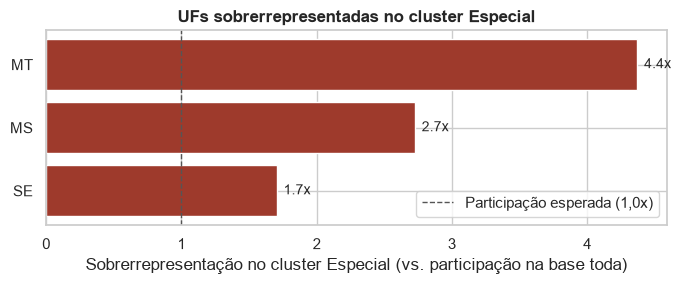

✓ uf_sobrerrepresentacao_especial.png salvo


In [24]:
razao_plot = razao[(n_especial_uf.reindex(razao.index).fillna(0) >= 10) & (razao >= 1.5)].sort_values()

fig, ax = plt.subplots(figsize=(7, max(3, 0.6 * len(razao_plot) + 1)))
rotulos_razao_sigla = [SIGLA_UF.get(uf, uf) for uf in razao_plot.index]
bars = ax.barh(rotulos_razao_sigla, razao_plot.values, color='#9E3A2C')
ax.axvline(1.0, color='#555555', linestyle='--', linewidth=1, label='Participação esperada (1,0x)')
for bar, v in zip(bars, razao_plot.values):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2, f'{v:.1f}x',
            va='center', fontsize=10)
ax.set_xlabel('Sobrerrepresentação no cluster Especial (vs. participação na base toda)')
ax.set_title('UFs sobrerrepresentadas no cluster Especial', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'uf_sobrerrepresentacao_especial.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ uf_sobrerrepresentacao_especial.png salvo')


### 5.6 Frete por cluster — testado como feature, mantido como enriquecimento

`frete_por_m3` foi testado como feature do K-Means e descartado por ablação (piorava silhueta e Davies-Bouldin ao mesmo tempo — `2.Kmeans.ipynb`, seção 13). Mas continua útil como enriquecimento pra entender o achado de UF acima.


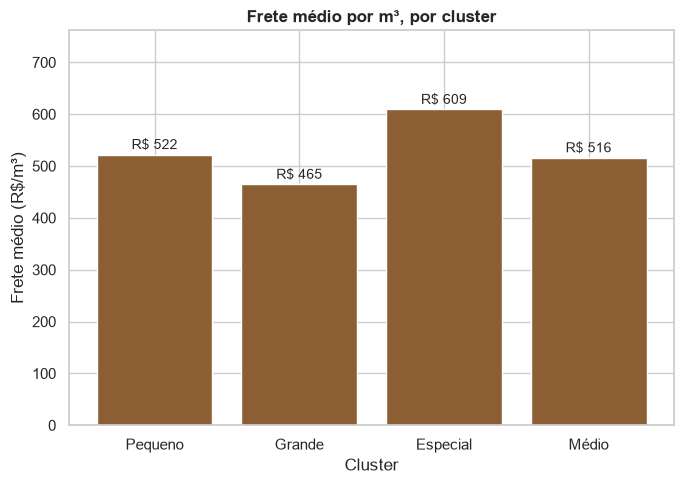

✓ frete_por_cluster.png salvo

Frete médio (R$/m³): Mato Grosso/MS vs. resto da base, dentro de cada cluster:


mean  count
cluster_nome mt_ms              
Especial     False  551.8    842
             True   918.8    156
Grande       False  455.6    255
             True   699.1     10
Médio        False  515.4   1097
             True   531.5     34
Pequeno      False  517.2   4561
             True   762.6     95

In [25]:
frete_por_cluster = segmentacao.groupby('cluster')['frete_por_m3'].mean()
rotulos_frete = [NOMES_CLUSTER[i] for i in frete_por_cluster.index]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(rotulos_frete, frete_por_cluster.values, color='#8B5E34')
for bar, v in zip(bars, frete_por_cluster.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5, f'R$ {v:.0f}',
            ha='center', va='bottom', fontsize=10)
ax.set_xlabel('Cluster'); ax.set_ylabel('Frete médio (R$/m³)')
ax.set_title('Frete médio por m³, por cluster', fontweight='bold')
ax.set_ylim(0, frete_por_cluster.max() * 1.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'frete_por_cluster.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ frete_por_cluster.png salvo')

print('\nFrete médio (R$/m³): Mato Grosso/MS vs. resto da base, dentro de cada cluster:')
segmentacao['mt_ms'] = segmentacao['estado_cliente'].isin(['Mato Grosso', 'Mato Grosso do Sul'])
segmentacao['cluster_nome'] = segmentacao['cluster'].map(NOMES_CLUSTER)
comparacao_frete = segmentacao.groupby(['cluster_nome', 'mt_ms'])['frete_por_m3'].agg(['mean', 'count'])
display(comparacao_frete.round(1))


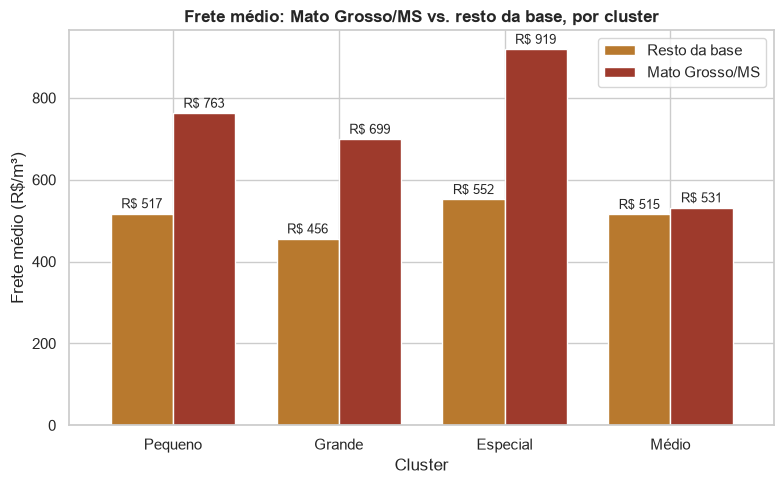

✓ frete_mtms_vs_resto_por_cluster.png salvo


In [26]:
pivot_frete_mtms = comparacao_frete['mean'].unstack('mt_ms')
pivot_frete_mtms = pivot_frete_mtms.reindex([NOMES_CLUSTER[k] for k in sorted(NOMES_CLUSTER)])
pivot_frete_mtms.columns = ['Resto da base', 'Mato Grosso/MS']

fig, ax = plt.subplots(figsize=(8, 5))
pivot_frete_mtms.plot(kind='bar', ax=ax, color=['#B8792E', '#9E3A2C'], width=0.75)
for container in ax.containers:
    ax.bar_label(container, fmt='R$ %.0f', fontsize=9, padding=2)
ax.set_xlabel('Cluster'); ax.set_ylabel('Frete médio (R$/m³)')
ax.set_title('Frete médio: Mato Grosso/MS vs. resto da base, por cluster', fontweight='bold')
plt.xticks(rotation=0)
ax.legend(title='')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'frete_mtms_vs_resto_por_cluster.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ frete_mtms_vs_resto_por_cluster.png salvo')


In [27]:
# Família principal por cliente (maior volume) -- nome real, sem bucket/Outras.
familia_por_cliente = (pricing_cluster.groupby(['Código Cliente', 'Prod - Família de Produtos'], observed=True)['volume']
    .sum().reset_index())
familia_principal = (familia_por_cliente.sort_values('volume', ascending=False)
    .drop_duplicates('Código Cliente')
    .set_index('Código Cliente')['Prod - Família de Produtos'])

segmentacao['familia_principal'] = segmentacao['Código Cliente'].map(familia_principal)
segmentacao['familia_principal'] = segmentacao['familia_principal'].fillna('Sem venda elegível')

segmentacao_completa = segmentacao[[
    'Código Cliente', 'nome_cliente', 'cnae_descricao', 'estado_cliente', 'cluster',
    'familia_principal', 'frequencia_mensal', 'nivel_frequencia', 'margem_pct_ponderada',
    'nivel_margem', 'frete_por_m3', 'receita_liquida_total'
]].copy()

segmentacao_completa.to_csv(OUTPUT_DIR / 'segmentacao_completa_cliente_cluster_familia.csv',
                             index=False, encoding='utf-8-sig')
print(f"✓ segmentacao_completa_cliente_cluster_familia.csv salvo ({len(segmentacao_completa):,} clientes)")
display(segmentacao_completa.head(10))


✓ segmentacao_completa_cliente_cluster_familia.csv salvo (7,050 clientes)


,Código Cliente,nome_cliente,cnae_descricao,estado_cliente,cluster,familia_principal,frequencia_mensal,nivel_frequencia,margem_pct_ponderada,nivel_margem,frete_por_m3,receita_liquida_total
0,1914210,CENTRAL FISH COMERCIO DE PESCADOS L,"Preservação de peixes, crustáceos e moluscos",Pará,0,COMPSOR RF,1.000000,Ocasionais,0.227481,Alta,329.650000,2637.58
1,1912219,M.G. CINDIO MANUTENCAO DE BOMBAS LT,Comércio atacadista de Máquinas e equipamentos...,São Paulo,0,HYDRA XP,1.000000,Ocasionais,0.059395,Baixa,519.785714,9421.24
2,1481,COMANDO DA MARINHA,Defesa,Ceará,0,MARBRAX CCD,1.000000,Ocasionais,0.177896,Média,385.854545,30071.51
3,1469,COMANDO DA MARINHA,Defesa,Rio de Janeiro,0,EXTRA TURBO,2.888889,Regulares,0.228668,Alta,302.098958,24465.84
4,1439,COMANDO DO EXERCITO,Defesa,Amazonas,0,EXTRA TURBO,1.000000,Ocasionais,0.052375,Baixa,232.660494,17552.40
5,1007,CENTRAIS ELETRICAS DO NORTE DO BRAS,Transmissão de energia elétrica,Pará,0,EXTRA TURBO,1.000000,Ocasionais,0.295789,Alta,293.833333,770.92
6,1006,CENTRAIS ELETRICAS DO NORTE DO BRAS,Transmissão de energia elétrica,Rondônia,0,TURBINA X,1.000000,Ocasionais,0.126201,Baixa,990.252500,45736.47
7,924,TRANSPORTADORA PLANALTO LTDA,Transporte rodoviário de produtos perigosos,Rondônia,0,TOP TURBO,2.000000,Regulares,0.154207,Média,912.468750,4572.05
8,618,CARAMURU ALIMENTOS S/A,"Fabricação de óleos vegetais refinados, exceto...",Goiás,0,TURBINA EP,1.192308,Ocasionais,0.158456,Média,568.046023,171324.81
9,574,CIPLAN CIMENTO PLANALTO SA,Preparação de massa de concreto e argamassa pa...,Goiás,0,HYDRA,1.450000,Ocasionais,0.143318,Média,259.680921,127684.04


In [28]:
# Frequência dominante por segmento (cluster × família consolidada)
seg_freq = segmentacao_completa.groupby(['cluster', 'familia_principal'], observed=True)['nivel_frequencia'] \
    .agg(lambda s: s.value_counts(normalize=True).idxmax() if len(s.dropna()) else np.nan)
seg_freq = seg_freq.astype(object)
seg_freq.name = 'frequencia_dominante'

segmentos = matriz_consolidada.rename(columns={'familia_final': 'familia_principal'}).merge(
    seg_freq.reset_index(), on=['cluster', 'familia_principal'], how='left'
)
print("SEGMENTOS FINAIS (cluster × família consolidada + frequência dominante)")
display(segmentos.sort_values(['cluster', 'volume_total'], ascending=[True, False]))


SEGMENTOS FINAIS (cluster × família consolidada + frequência dominante)


,cluster,familia_principal,clientes_unicos,volume_total,receita_liquida_total,lucro_reposicao_total,preco_ponderado,margem_pct_ponderada,frequencia_dominante
5,0,TOP TURBO,2892,5502.23,6.365654e+07,9757129.28,11569.224800,15.327773,Ocasionais
4,0,HYDRA XP,1541,1900.80,2.033035e+07,4040531.44,10695.678614,19.874386,Ocasionais
3,0,HYDRA,937,921.46,9.340641e+06,1736195.22,10136.784006,18.587538,Ocasionais
2,0,GL 5,1594,836.60,1.071415e+07,1687506.61,12806.774612,15.750265,Ocasionais
6,0,TOP TURBO PRO,738,686.70,9.370699e+06,1278453.99,13645.986661,13.643102,Ocasionais
1,0,GEAR,657,674.71,8.758281e+06,1752411.84,12980.807562,20.008628,Ocasionais
9,0,UTILE,405,543.94,6.369756e+06,1262536.59,11710.401184,19.820801,Ocasionais
7,0,TRM 5,881,424.45,6.017179e+06,868078.74,14176.415337,14.426672,Ocasionais
8,0,UNITRACTOR,613,353.84,4.594383e+06,743570.41,12984.350950,16.184338,Ocasionais
0,0,FLUIDO PARA RADIADOR,459,257.31,3.490211e+06,471316.47,13564.225992,13.503954,Ocasionais


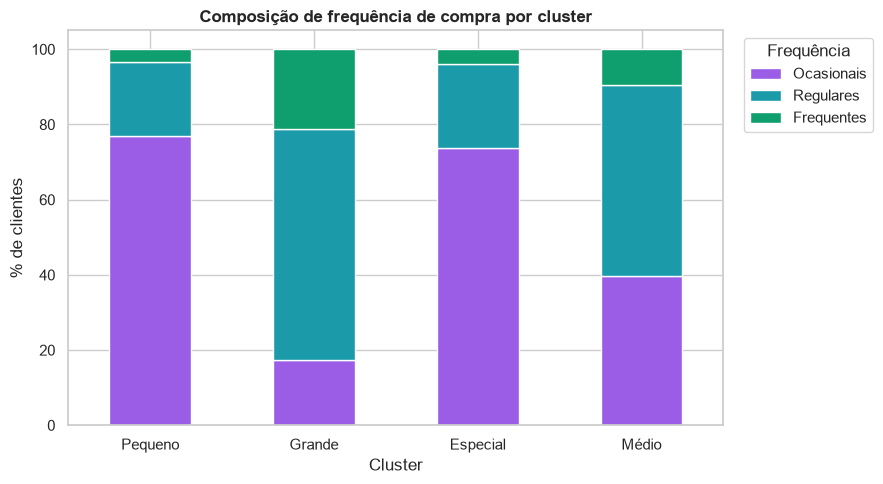

✓ frequencia_por_cluster.png salvo


In [29]:
freq_por_cluster = pd.crosstab(segmentacao['cluster'], segmentacao['nivel_frequencia'], normalize='index') * 100
freq_por_cluster = freq_por_cluster[['Ocasionais', 'Regulares', 'Frequentes']]
freq_por_cluster.index = freq_por_cluster.index.map(NOMES_CLUSTER)

fig, ax = plt.subplots(figsize=(9, 5))
freq_por_cluster.plot(kind='bar', stacked=True, ax=ax, color=['#9B5DE5', '#1B9AAA', '#0F9F6E'])
ax.set_xlabel('Cluster'); ax.set_ylabel('% de clientes')
ax.set_title('Composição de frequência de compra por cluster', fontweight='bold')
ax.legend(title='Frequência', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'frequencia_por_cluster.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ frequencia_por_cluster.png salvo')


## 6. Análise de concentração (Pareto)

16 de 40 segmentos cobrem 80% da receita total.


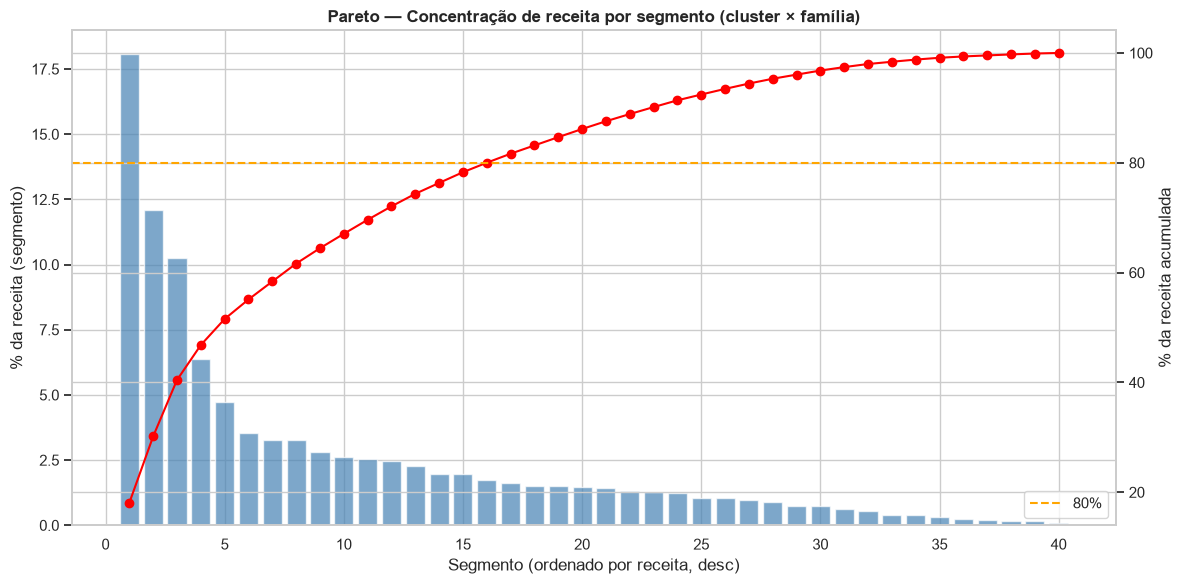

✓ pareto_segmentos.png salvo
✓ segmentos_pareto.csv salvo


In [30]:
pareto = segmentos.copy()
pareto['receita_pct'] = pareto['receita_liquida_total'] / pareto['receita_liquida_total'].sum() * 100
pareto = pareto.sort_values('receita_pct', ascending=False).reset_index(drop=True)
pareto['receita_pct_acumulado'] = pareto['receita_pct'].cumsum()
pareto['segmento_rank'] = np.arange(1, len(pareto) + 1)

n_para_80 = int((pareto['receita_pct_acumulado'] < 80).sum() + 1)
print(f"{n_para_80} de {len(pareto)} segmentos cobrem 80% da receita total.")

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(pareto['segmento_rank'], pareto['receita_pct'], color='steelblue', alpha=0.7)
ax2 = ax.twinx()
ax2.plot(pareto['segmento_rank'], pareto['receita_pct_acumulado'], color='red', marker='o')
ax2.axhline(80, color='orange', linestyle='--', label='80%')
ax.set_xlabel('Segmento (ordenado por receita, desc)')
ax.set_ylabel('% da receita (segmento)')
ax2.set_ylabel('% da receita acumulada')
ax.set_title('Pareto — Concentração de receita por segmento (cluster × família)', fontweight='bold')
ax2.legend(loc='lower right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pareto_segmentos.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ pareto_segmentos.png salvo")

pareto.to_csv(OUTPUT_DIR / 'segmentos_pareto.csv', index=False, encoding='utf-8-sig')
print("✓ segmentos_pareto.csv salvo")

## 7. Validação cruzada — amostra de clientes por segmento

In [31]:
amostras = []
for (cluster_id, familia), grupo in segmentacao_completa.groupby(['cluster', 'familia_principal'], observed=True):
    amostras.append(grupo.sample(min(2, len(grupo)), random_state=42))
amostra_df = pd.concat(amostras).sort_values(['cluster', 'familia_principal'])
display(amostra_df[['nome_cliente', 'cluster', 'familia_principal', 'nivel_frequencia',
                     'frequencia_mensal', 'receita_liquida_total']].head(30))
print(f"\n{len(amostra_df)} clientes amostrados (até 2 por segmento) para validação manual.")

,nome_cliente,cluster,familia_principal,nivel_frequencia,frequencia_mensal,receita_liquida_total
2500,VILA BOA CONSTRUCOES E SERVICOS LIM,0,2T,Ocasionais,1.260870,28439.87
3959,NAG - ENGENHARIA LTDA,0,2T,Ocasionais,1.000000,16535.09
1086,RAPIDO FENIX VIACAO LTDA,0,ATF,Regulares,2.000000,12296.35
1747,TRANSPORTADORA SAO JOSE DO TOCANTIN,0,ATF,Ocasionais,1.000000,4589.42
3805,SILPAR TRANSPORTE RODOVIARIO LTDA,0,ATF TA,Ocasionais,1.000000,1063.56
2200,RAPIDO LUXO CAMPINAS LTDA,0,ATF TA,Ocasionais,1.000000,4557.47
4413,TRANS INA TRANSPORTES LTDA,0,AUTOLITH,Ocasionais,1.272727,18841.63
2819,JSL S/A.,0,AUTOLITH,Ocasionais,1.333333,25668.85
917,VIACAO PLANETA LTDA,0,AVANTE,Ocasionais,1.000000,9046.22
1568,MINERACAO VERA CRUZ LTDA,0,CALCIUM,Ocasionais,1.500000,3257.57



351 clientes amostrados (até 2 por segmento) para validação manual.


## 8. Visualizações

### Top 10 famílias: quanto pesam no volume e na receita de cada cluster

As 10 famílias com maior volume na base toda, e a participação de cada uma no volume e na receita líquida de cada cluster.


Cobertura do top 10 (% do total do cluster coberto pelas 10 famílias líderes):


,% volume,% receita
Pequeno,73.2,69.7
Grande,70.3,65.2
Especial,52.0,44.8
Médio,71.6,66.0


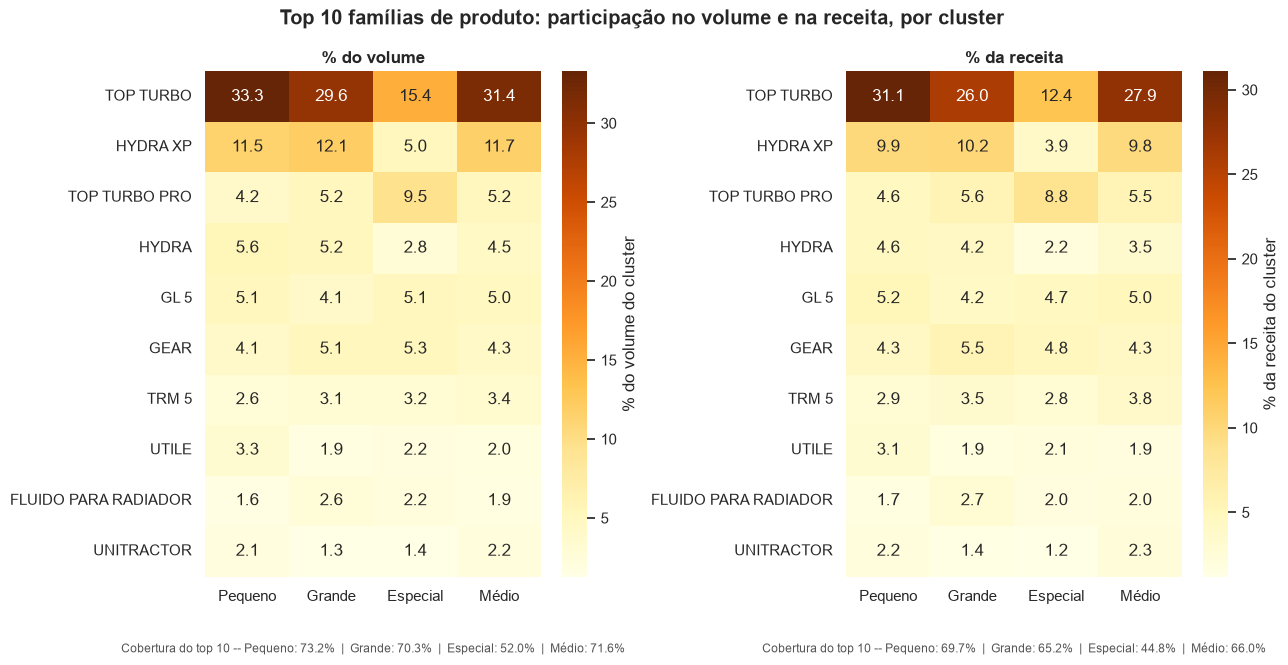

✓ top10_familias_volume_receita_cluster.png salvo


In [32]:
top10_familias_geral = (pricing_cluster.groupby('Prod - Família de Produtos', observed=True)['volume']
    .sum().sort_values(ascending=False).head(10))

pricing_marcado = pricing_cluster.copy()
pricing_marcado['fam_marcada'] = np.where(
    pricing_marcado['Prod - Família de Produtos'].isin(top10_familias_geral.index),
    pricing_marcado['Prod - Família de Produtos'], '__resto__')

# Normaliza contra o TOTAL do cluster (incluindo o resto), não só contra o top 10 --
# assim a % de cada família é a participação real, e a cobertura é 100% - resto%.
vol_pivot_full = (pd.crosstab(pricing_marcado['fam_marcada'], pricing_marcado['cluster'],
    values=pricing_marcado['volume'], aggfunc='sum', normalize='columns') * 100)
rec_pivot_full = (pd.crosstab(pricing_marcado['fam_marcada'], pricing_marcado['cluster'],
    values=pricing_marcado['receita_liquida'], aggfunc='sum', normalize='columns') * 100)

cobertura_volume = 100 - vol_pivot_full.loc['__resto__']
cobertura_receita = 100 - rec_pivot_full.loc['__resto__']

vol_pivot = vol_pivot_full.drop('__resto__').reindex(top10_familias_geral.index)
rec_pivot = rec_pivot_full.drop('__resto__').reindex(top10_familias_geral.index)
rotulos_cluster_fam = [NOMES_CLUSTER[c] for c in vol_pivot.columns]
vol_pivot.columns = rotulos_cluster_fam
rec_pivot.columns = rotulos_cluster_fam
cobertura_volume.index = [NOMES_CLUSTER[c] for c in cobertura_volume.index]
cobertura_receita.index = [NOMES_CLUSTER[c] for c in cobertura_receita.index]

print('Cobertura do top 10 (% do total do cluster coberto pelas 10 famílias líderes):')
cobertura_tabela = pd.DataFrame({'% volume': cobertura_volume.round(1), '% receita': cobertura_receita.round(1)})
display(cobertura_tabela)

fig, axes = plt.subplots(1, 2, figsize=(13, 6.8))
sns.heatmap(vol_pivot, annot=True, fmt='.1f', cmap='YlOrBr', ax=axes[0],
            cbar_kws={'label': '% do volume do cluster'})
axes[0].set_title('% do volume', fontweight='bold'); axes[0].set_xlabel(''); axes[0].set_ylabel('')

sns.heatmap(rec_pivot, annot=True, fmt='.1f', cmap='YlOrBr', ax=axes[1],
            cbar_kws={'label': '% da receita do cluster'})
axes[1].set_title('% da receita', fontweight='bold'); axes[1].set_xlabel(''); axes[1].set_ylabel('')

for ax, cobertura in zip(axes, [cobertura_volume, cobertura_receita]):
    texto = '  |  '.join(f'{c}: {v:.1f}%' for c, v in cobertura.items())
    ax.text(0.5, -0.15, f'Cobertura do top 10 -- {texto}', transform=ax.transAxes,
            ha='center', fontsize=8.8, color='#555555')

fig.suptitle('Top 10 famílias de produto: participação no volume e na receita, por cluster', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top10_familias_volume_receita_cluster.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ top10_familias_volume_receita_cluster.png salvo')


**Achado:** o Especial tem menos concentração nas famílias líderes — TOP TURBO cai para ~15% do volume e ~12% da receita (contra ~30% nos outros três clusters) — e a cobertura do top 10 cai para **~52% do volume e ~45% da receita**, contra **~65%–73%** nos outros três grupos. Ou seja, quase metade do volume/receita do Especial vem de fora das 10 famílias mais vendidas da base — o mix de produtos do Especial já é um pouco mais disperso. Mas isso sozinho não explica a diferença de preço/margem vista antes — o achado de margem unitária (acima) já mostrou que a queda de margem acontece em toda família, dispersa ou não.


### Top 10 famílias — só dentro do cluster Especial

O top 10 acima é o mesmo para os 4 clusters (as famílias mais vendidas na base toda). Mas será que o Especial, que já é menos concentrado nas famílias líderes, compra as **mesmas** 10 famílias em proporções diferentes, ou compra famílias **diferentes**? Recalculando o top 10 usando só as transações do Especial:


Famílias no top 10 do Especial que NÃO estão no top 10 da base toda: ['LITH EP', 'LITHPLUS EP', 'TOP TURBO AVANTE', 'TRM 5 PLUS']

Cobertura do top 10 do Especial (sobre o próprio Especial): volume 60.4% | receita 56.8%


,volume_total,receita_total,pct_volume,pct_receita,preco_ponderado
Prod - Família de Produtos,,,,,
TOP TURBO,444.37,6527327.77,15.39,12.37,14688.95
TOP TURBO PRO,273.68,4635022.64,9.48,8.78,16935.92
TOP TURBO AVANTE,161.83,3706426.81,5.61,7.02,22903.21
GEAR,152.30,2532817.76,5.28,4.80,16630.45
GL 5,147.70,2463140.40,5.12,4.67,16676.64
HYDRA XP,145.37,2051987.41,5.04,3.89,14115.62
LITHPLUS EP,140.36,3149139.88,4.86,5.97,22436.16
TRM 5 PLUS,97.98,1731907.71,3.39,3.28,17676.14
TRM 5,92.49,1487358.98,3.20,2.82,16081.30


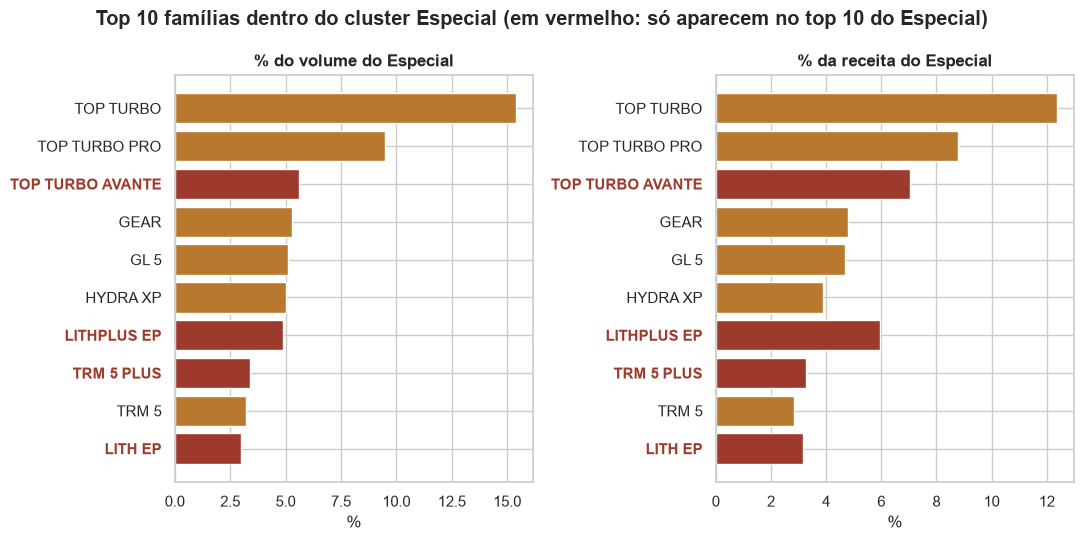

✓ top10_familias_especial.png salvo


In [33]:
pricing_especial = pricing_cluster[pricing_cluster['cluster'] == especial_id]
top10_especial = (pricing_especial.groupby('Prod - Família de Produtos', observed=True)['volume']
    .sum().sort_values(ascending=False).head(10))

exclusivas_especial = sorted(set(top10_especial.index) - set(top10_familias_geral.index))
print(f"Famílias no top 10 do Especial que NÃO estão no top 10 da base toda: {exclusivas_especial}")

vol_total_especial = pricing_especial['volume'].sum()
rec_total_especial = pricing_especial['receita_liquida'].sum()

g_esp = pricing_especial.groupby('Prod - Família de Produtos', observed=True).agg(
    volume_total=('volume', 'sum'), receita_total=('receita_liquida', 'sum')).loc[top10_especial.index]
g_esp['pct_volume'] = g_esp['volume_total'] / vol_total_especial * 100
g_esp['pct_receita'] = g_esp['receita_total'] / rec_total_especial * 100
g_esp['preco_ponderado'] = g_esp['receita_total'] / g_esp['volume_total']

print(f"\nCobertura do top 10 do Especial (sobre o próprio Especial): "
      f"volume {g_esp['pct_volume'].sum():.1f}% | receita {g_esp['pct_receita'].sum():.1f}%")
display(g_esp.round(2))

cores_barras = ['#9E3A2C' if fam in exclusivas_especial else '#B8792E' for fam in g_esp.index]
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
axes[0].barh(g_esp.index[::-1], g_esp['pct_volume'][::-1], color=cores_barras[::-1])
axes[0].set_title('% do volume do Especial', fontweight='bold'); axes[0].set_xlabel('%')
axes[1].barh(g_esp.index[::-1], g_esp['pct_receita'][::-1], color=cores_barras[::-1])
axes[1].set_title('% da receita do Especial', fontweight='bold'); axes[1].set_xlabel('%')
for ax in axes:
    for lbl in ax.get_yticklabels():
        if lbl.get_text() in exclusivas_especial:
            lbl.set_color('#9E3A2C'); lbl.set_fontweight('bold')
fig.suptitle('Top 10 famílias dentro do cluster Especial (em vermelho: só aparecem no top 10 do Especial)', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top10_familias_especial.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ top10_familias_especial.png salvo')


**Achado:** 4 das 10 famílias do top do Especial (**TOP TURBO AVANTE**, **LITHPLUS EP**, **TRM 5 PLUS**, **LITH EP**) não aparecem no top 10 da base toda — o Especial não compra só menos concentrado, compra **produtos parcialmente diferentes**. Em compensação, 4 famílias do top 10 geral (FLUIDO PARA RADIADOR, HYDRA, UNITRACTOR, UTILE) nem entram no top 10 do Especial. Olhando o próprio Especial, o top 10 cobre 60,4% do volume e 56,8% da receita — mais alto que os 52,0%/44,8% do top 10 *geral* aplicado ao Especial (seção anterior), porque agora as 10 famílias são as que o Especial de fato mais compra.


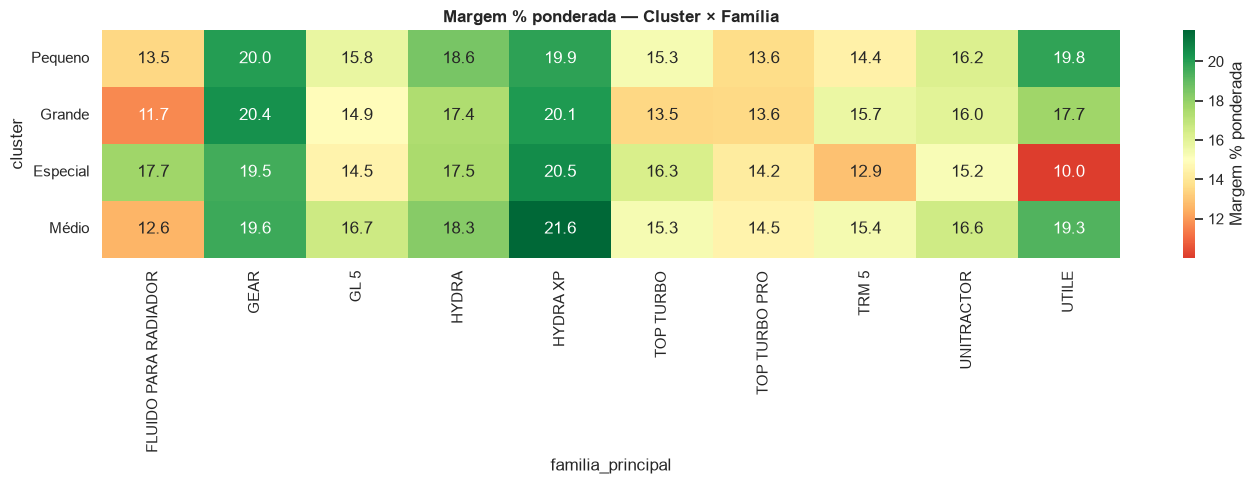

✓ heatmap_margem_cluster_familia.png salvo


In [34]:
# Heatmap: margem % ponderada por cluster x família
pivot_margem = segmentos.pivot(index='cluster', columns='familia_principal', values='margem_pct_ponderada')
rotulos_margem = [NOMES_CLUSTER[i] for i in pivot_margem.index]
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot_margem, annot=True, fmt='.1f', cmap='RdYlGn', center=15, ax=ax,
            yticklabels=rotulos_margem, cbar_kws={'label': 'Margem % ponderada'})
ax.set_yticklabels(rotulos_margem, rotation=0, va='center')
ax.set_title('Margem % ponderada — Cluster × Família', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'heatmap_margem_cluster_familia.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ heatmap_margem_cluster_familia.png salvo")

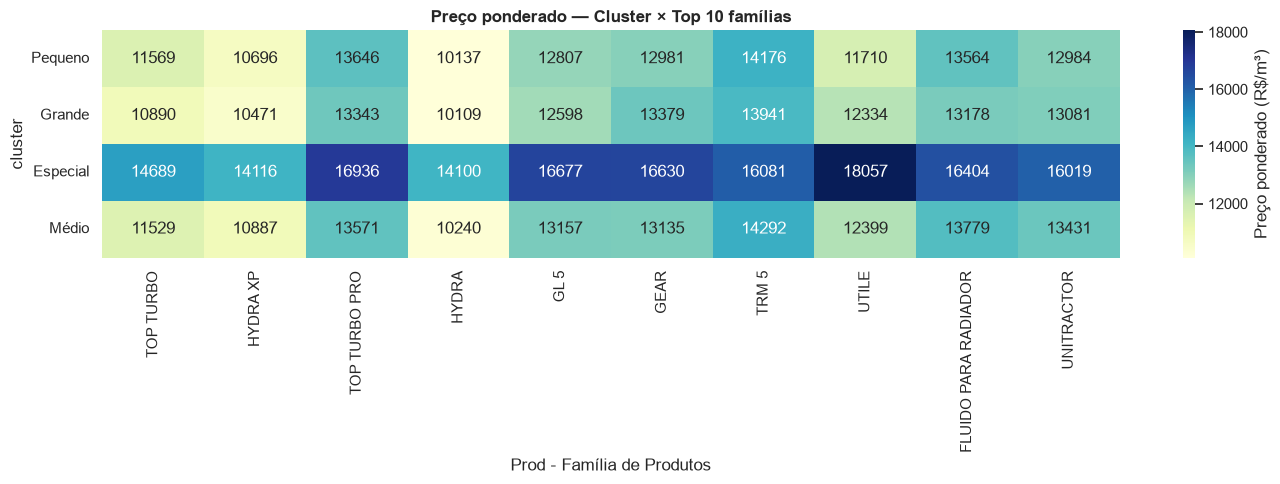

✓ heatmap_preco_cluster_familia.png salvo (top 10 famílias, sem 'Outras')


In [35]:
# Heatmap: preço ponderado por cluster x top 10 famílias (sem 'Outras' -- mesmo top 10 do card acima)
pt10_price = pricing_cluster[pricing_cluster['Prod - Família de Produtos'].isin(top10_familias_geral.index)].copy()
g_price = pt10_price.groupby(['cluster', 'Prod - Família de Produtos'], observed=True).agg(
    volume_total=('volume', 'sum'), receita_total=('receita_liquida', 'sum'))
g_price['preco_ponderado'] = g_price['receita_total'] / g_price['volume_total']

pivot_preco = g_price['preco_ponderado'].unstack()[top10_familias_geral.index]
rotulos_preco = [NOMES_CLUSTER[i] for i in pivot_preco.index]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot_preco, annot=True, fmt='.0f', cmap='YlGnBu', ax=ax,
            yticklabels=rotulos_preco, cbar_kws={'label': 'Preço ponderado (R$/m³)'})
ax.set_yticklabels(rotulos_preco, rotation=0, va='center')
ax.set_title('Preço ponderado — Cluster × Top 10 famílias', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'heatmap_preco_cluster_familia.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ heatmap_preco_cluster_familia.png salvo (top 10 famílias, sem 'Outras')")


### Preço ponderado — top 10 específico do Especial

O heatmap acima usa o top 10 *geral*. Olhando o preço só nas famílias que o próprio Especial mais compra (incluindo as 4 exclusivas):


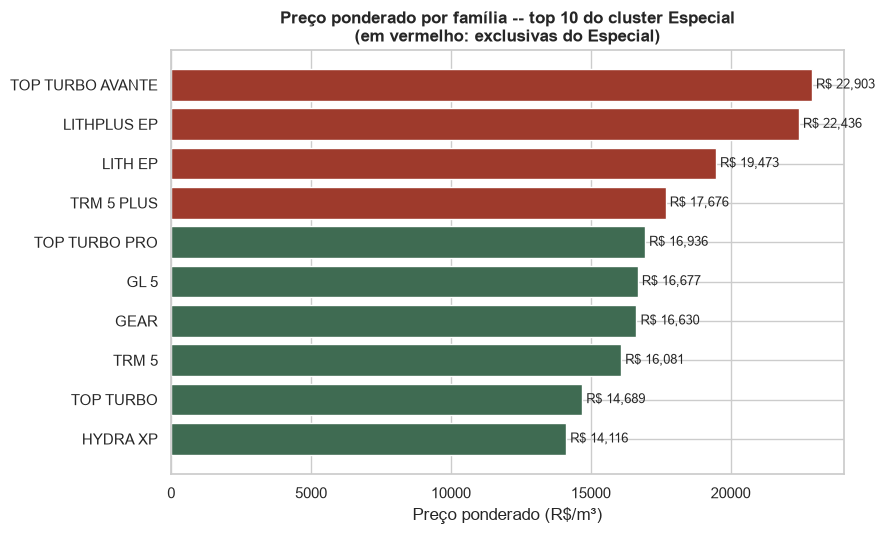

✓ preco_top10_familias_especial.png salvo


In [36]:
g_esp_sorted = g_esp.sort_values('preco_ponderado', ascending=True)
cores_preco = ['#9E3A2C' if fam in exclusivas_especial else '#3F6B52' for fam in g_esp_sorted.index]

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(g_esp_sorted.index, g_esp_sorted['preco_ponderado'], color=cores_preco)
for bar, v in zip(bars, g_esp_sorted['preco_ponderado']):
    ax.text(bar.get_width() + 150, bar.get_y() + bar.get_height() / 2, f'R$ {v:,.0f}',
            va='center', fontsize=9.5)
ax.set_xlabel('Preço ponderado (R$/m³)')
ax.set_title('Preço ponderado por família -- top 10 do cluster Especial\n(em vermelho: exclusivas do Especial)', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'preco_top10_familias_especial.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ preco_top10_familias_especial.png salvo')


**Achado:** as 2 famílias exclusivas do Especial com maior volume são também as **mais caras** de toda a lista — **TOP TURBO AVANTE** (R$ 22.903/m³) e **LITHPLUS EP** (R$ 22.436/m³), acima até do pico visto no top 10 geral (R$ 18.057/m³ em UTILE, seção anterior). O mix específico do Especial não é só diferente — é mais caro ainda do que a comparação com o top 10 geral já mostrava.


### Margem unitária — top 10 específico do Especial

Complementando o preço acima: qual a margem unitária (R$/m³) de cada um desses 10 produtos, e em que faixa de margem (Baixa/Média/Alta, seção 6.3) cada um cai?


,preco_ponderado,margem_pct,margem_unitaria,nivel_margem
Prod - Família de Produtos,,,,
TOP TURBO,14688.95,16.33,2398.98,Média
TOP TURBO PRO,16935.92,14.20,2405.33,Média
TOP TURBO AVANTE,22903.21,11.97,2740.92,Baixa
GEAR,16630.45,19.54,3249.63,Alta
GL 5,16676.64,14.52,2421.88,Média
HYDRA XP,14115.62,20.54,2898.69,Alta
LITHPLUS EP,22436.16,11.01,2469.33,Baixa
TRM 5 PLUS,17676.14,11.06,1954.71,Baixa
TRM 5,16081.30,12.88,2070.86,Baixa


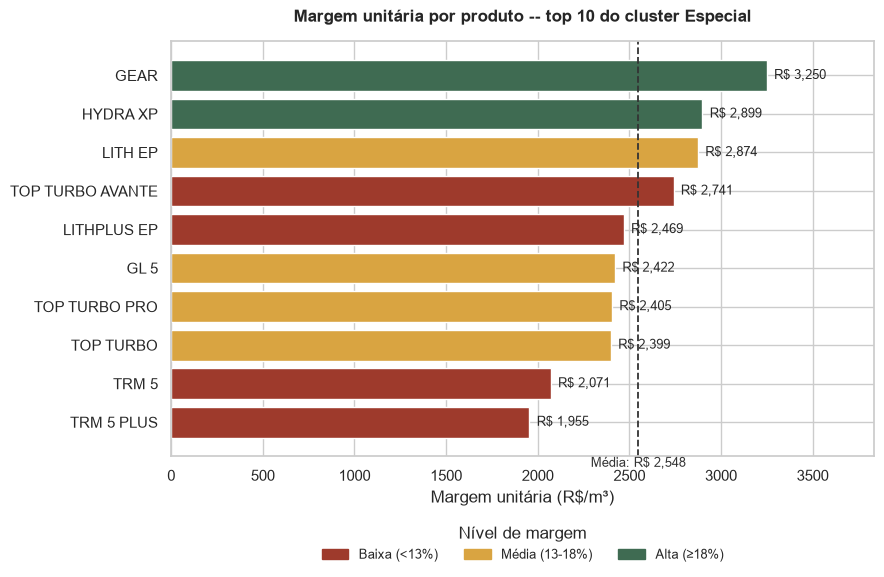

✓ margem_unitaria_top10_especial.png salvo


In [37]:
g_esp['lucro_total'] = pricing_especial[pricing_especial['Prod - Família de Produtos'].isin(top10_especial.index)]\
    .groupby('Prod - Família de Produtos', observed=True)['lucro_reposicao'].sum().loc[g_esp.index]
g_esp['margem_pct'] = g_esp['lucro_total'] / g_esp['receita_total'] * 100
g_esp['margem_unitaria'] = g_esp['lucro_total'] / g_esp['volume_total']
g_esp['custo_pct'] = 100 - g_esp['margem_pct']

def tier(m):
    if m < 13: return 'Baixa'
    elif m < 18: return 'Média'
    return 'Alta'

g_esp['nivel_margem'] = g_esp['margem_pct'].apply(tier)
cores_tier = {'Baixa': '#9E3A2C', 'Média': '#D9A441', 'Alta': '#3F6B52'}
display(g_esp[['preco_ponderado', 'margem_pct', 'margem_unitaria', 'nivel_margem']].round(2))

g_esp_sorted = g_esp.sort_values('margem_unitaria', ascending=True)
media_margem_unit = g_esp['margem_unitaria'].mean()

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(g_esp_sorted.index, g_esp_sorted['margem_unitaria'],
                color=[cores_tier[t] for t in g_esp_sorted['nivel_margem']])
for bar, v in zip(bars, g_esp_sorted['margem_unitaria']):
    ax.text(bar.get_width() + 40, bar.get_y() + bar.get_height() / 2, f'R$ {v:,.0f}',
            va='center', fontsize=9.5)
ax.axvline(media_margem_unit, color='#333333', linestyle='--', linewidth=1.3)
ax.text(media_margem_unit, -0.9, f'Média: R$ {media_margem_unit:,.0f}', ha='center', va='top',
         fontsize=9, color='#333333')
ax.set_xlabel('Margem unitária (R$/m³)')
ax.set_title('Margem unitária por produto -- top 10 do cluster Especial', fontweight='bold', pad=14)
ax.set_xlim(0, g_esp_sorted['margem_unitaria'].max() * 1.18)
handles = [plt.Rectangle((0, 0), 1, 1, color=cores_tier[t]) for t in ['Baixa', 'Média', 'Alta']]
ax.legend(handles, ['Baixa (<13%)', 'Média (13-18%)', 'Alta (\u226518%)'],
          loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=3, frameon=False, fontsize=9.5,
          title='Nível de margem')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'margem_unitaria_top10_especial.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ margem_unitaria_top10_especial.png salvo')


**Achado:** as duas famílias mais caras do top 10 do Especial — **TOP TURBO AVANTE** e **LITHPLUS EP** — estão na faixa de margem **Baixa** (11,0%–12,0%), não na Alta. Preço mais alto não está virando margem melhor nesses produtos; o custo deles cresce proporcionalmente ainda mais. Já GEAR e HYDRA XP, com preço no meio da tabela, são as únicas com margem **Alta** (19,5%–20,5%). Das 4 famílias exclusivas do Especial, 3 (TOP TURBO AVANTE, LITHPLUS EP, TRM 5 PLUS) estão na faixa Baixa — reforça a hipótese de custo (frete/logística) específico desses produtos de nicho.


### Margem vs. custo — top 10 específico do Especial

Cada produto como uma bolha: eixo = margem (%) e custo (% do preço) — como são complementares (margem % + custo % = 100%), a posição na diagonal mostra o trade-off; o tamanho da bolha é a margem unitária em R$/m³ (o que realmente entra no caixa por m³ vendido), e a cor é o nível de margem.


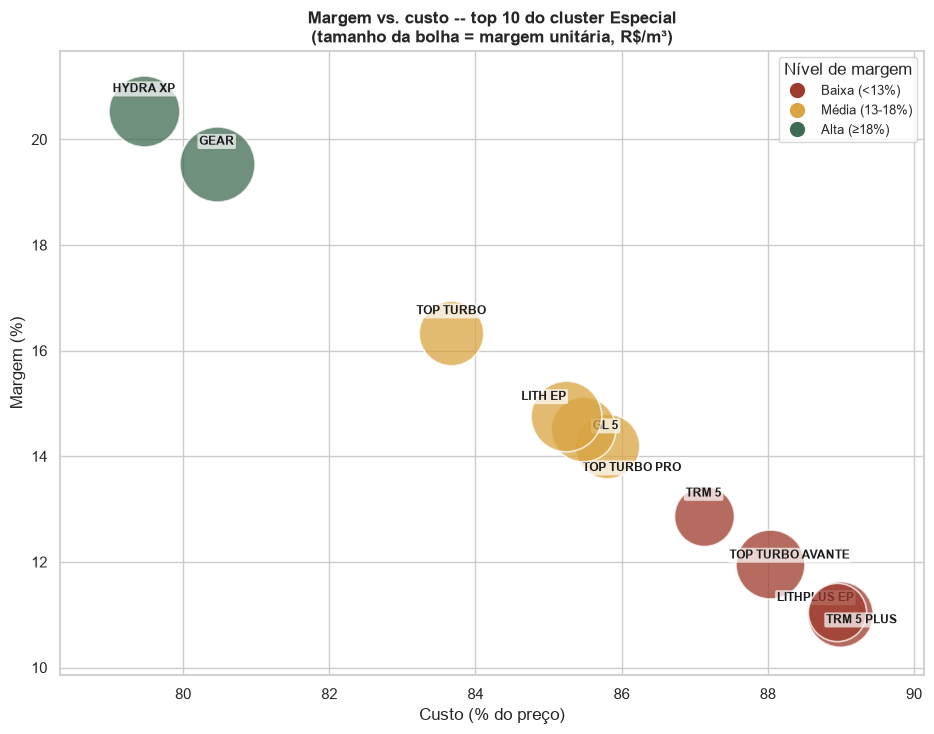

✓ bolha_margem_custo_especial.png salvo


In [38]:
offsets = {
    'LITH EP': (-16, 14), 'GL 5': (16, 2), 'TOP TURBO PRO': (18, -16),
    'LITHPLUS EP': (-18, 12), 'TRM 5 PLUS': (18, -6),
    'HYDRA XP': (0, 16), 'GEAR': (0, 16), 'TOP TURBO': (0, 16),
    'TRM 5': (0, 16), 'TOP TURBO AVANTE': (14, 6),
}

fig, ax = plt.subplots(figsize=(9.5, 7.5))
for fam, row in g_esp.iterrows():
    ax.scatter(row['custo_pct'], row['margem_pct'], s=row['margem_unitaria'] * 0.9,
               color=cores_tier[row['nivel_margem']], alpha=0.75, edgecolor='white', linewidth=1.2, zorder=3)
    dx, dy = offsets.get(fam, (0, 16))
    ax.annotate(fam, (row['custo_pct'], row['margem_pct']), xytext=(dx, dy), textcoords='offset points',
                ha='center', va='center', fontsize=8.5, fontweight='bold', color='#1a1a1a',
                bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.7))

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cores_tier[t], markersize=12) for t in ['Baixa', 'Média', 'Alta']]
ax.legend(handles, ['Baixa (<13%)', 'Média (13-18%)', 'Alta (\u226518%)'], loc='upper right', fontsize=9.5, title='Nível de margem')
ax.set_xlabel('Custo (% do preço)')
ax.set_ylabel('Margem (%)')
ax.set_title('Margem vs. custo -- top 10 do cluster Especial\n(tamanho da bolha = margem unitária, R$/m³)', fontweight='bold')
ax.margins(x=0.12, y=0.12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'bolha_margem_custo_especial.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ bolha_margem_custo_especial.png salvo')


**Achado:** as bolhas vermelhas (margem Baixa) ficam concentradas no canto de **maior custo relativo** (canto inferior direito) — exatamente onde estão as famílias exclusivas mais caras do Especial. As bolhas verdes (margem Alta) ficam no canto oposto, com custo relativo bem menor. O tamanho das bolhas (margem unitária em R$) não segue a mesma ordem do preço — GEAR e HYDRA XP (bolhas verdes) têm bolhas relativamente grandes mesmo sem serem os produtos mais caros.


### O frete explica a margem baixa desses produtos?

A hipótese natural, dado tudo que vimos até aqui sobre frete/UF, é que os produtos de margem Baixa custem mais para entregar. Testamos: qual o frete médio dos clientes que compram esses produtos, dentro do próprio Especial, comparado aos que compram os outros produtos do top 10?


Produtos com margem Baixa no top 10 do Especial (4): ['LITHPLUS EP', 'TRM 5 PLUS', 'TOP TURBO AVANTE', 'TRM 5']
Frete médio -- compram produto(s) de margem Baixa: R$ 559/m³ (n=440)
Frete médio -- compram só outros produtos do top 10: R$ 678/m³ (n=411)


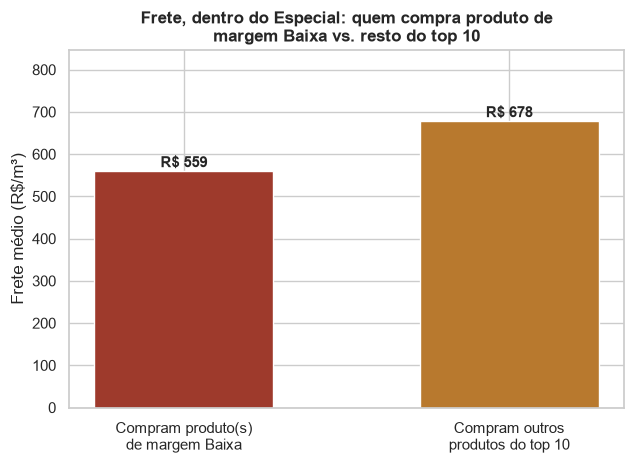

✓ frete_produtos_margem_baixa.png salvo


In [39]:
produtos_baixa = g_esp[g_esp['nivel_margem'] == 'Baixa'].sort_values('margem_pct').index.tolist()
print(f"Produtos com margem Baixa no top 10 do Especial ({len(produtos_baixa)}): {produtos_baixa}")

clientes_baixa_prod = set(pricing_especial.loc[
    pricing_especial['Prod - Família de Produtos'].isin(produtos_baixa), 'Código Cliente'])
clientes_outros_top10 = set(pricing_especial.loc[
    pricing_especial['Prod - Família de Produtos'].isin(top10_especial.index), 'Código Cliente']
    ) - clientes_baixa_prod

frete_especial_map = segmentacao.set_index('Código Cliente')['frete_por_m3']
frete_baixa = frete_especial_map.reindex(list(clientes_baixa_prod)).mean()
frete_outros = frete_especial_map.reindex(list(clientes_outros_top10)).mean()
print(f"Frete médio -- compram produto(s) de margem Baixa: R$ {frete_baixa:.0f}/m³ (n={len(clientes_baixa_prod)})")
print(f"Frete médio -- compram só outros produtos do top 10: R$ {frete_outros:.0f}/m³ (n={len(clientes_outros_top10)})")

fig, ax = plt.subplots(figsize=(6.5, 4.8))
bars = ax.bar(['Compram produto(s)\nde margem Baixa', 'Compram outros\nprodutos do top 10'],
              [frete_baixa, frete_outros], color=['#9E3A2C', '#B8792E'], width=0.55)
for bar, v in zip(bars, [frete_baixa, frete_outros]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10, f'R$ {v:.0f}',
            ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Frete médio (R$/m³)')
ax.set_title('Frete, dentro do Especial: quem compra produto de\nmargem Baixa vs. resto do top 10', fontweight='bold')
ax.set_ylim(0, max(frete_baixa, frete_outros) * 1.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'frete_produtos_margem_baixa.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ frete_produtos_margem_baixa.png salvo')


**Achado: não é frete.** O frete médio de quem compra os produtos de margem Baixa (R$ 559/m³, n=440) é, na verdade, **menor** que o de quem compra os outros produtos do top 10 (R$ 678/m³, n=411) — o frete não explica a margem apertada desses 4 produtos especificamente. O achado de frete/UF (seção 6.2) segue válido no nível agregado do cluster, mas não é a causa da margem baixa desses produtos em particular.


### Produtos com margem Baixa no Especial: quantos são, e onde são vendidos

4 dos 10 produtos do top 10 do Especial caem na faixa de margem Baixa: **TOP TURBO AVANTE**, **LITHPLUS EP**, **TRM 5 PLUS** e **TRM 5**. Em quais UF esses clientes estão?


440 clientes únicos (44.1% do Especial) compram pelo menos um desses 4 produtos


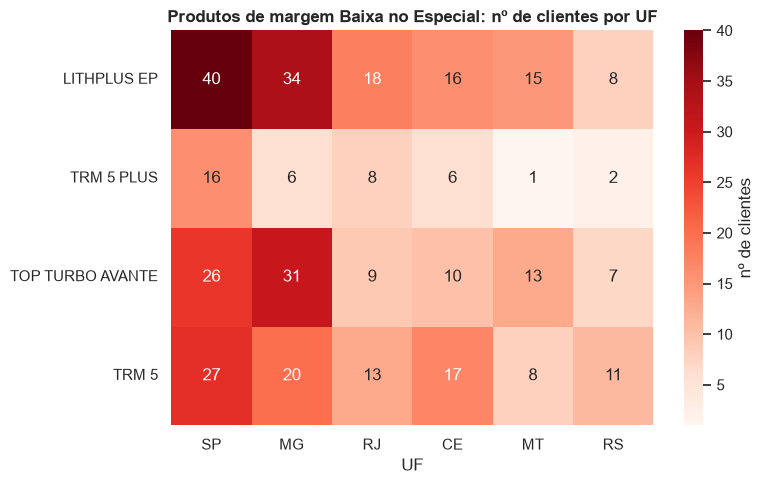

✓ clientes_uf_produtos_margem_baixa.png salvo


In [40]:
estado_map_pc = segmentacao.set_index('Código Cliente')['estado_cliente']
pricing_especial = pricing_especial.copy()
pricing_especial['estado_cliente'] = pricing_especial['Código Cliente'].map(estado_map_pc)

sub_baixa = pricing_especial[pricing_especial['Prod - Família de Produtos'].isin(produtos_baixa)]
n_clientes_uniao = sub_baixa['Código Cliente'].nunique()
print(f"{n_clientes_uniao:,} clientes únicos ({n_clientes_uniao / len(clientes_especial_todos) * 100:.1f}% "
      f"do Especial) compram pelo menos um desses {len(produtos_baixa)} produtos")

top_uf_baixa = (sub_baixa.groupby('estado_cliente', observed=True)['Código Cliente']
    .nunique().sort_values(ascending=False).head(6).index)
n_cliente_prod_uf = (sub_baixa[sub_baixa['estado_cliente'].isin(top_uf_baixa)]
    .groupby(['Prod - Família de Produtos', 'estado_cliente'], observed=True)['Código Cliente']
    .nunique().unstack(fill_value=0).reindex(produtos_baixa)[top_uf_baixa])
rotulos_uf_baixa = [SIGLA_UF.get(uf, uf) for uf in n_cliente_prod_uf.columns]

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(n_cliente_prod_uf, annot=True, fmt='d', cmap='Reds', ax=ax,
            xticklabels=rotulos_uf_baixa, cbar_kws={'label': 'nº de clientes'})
ax.set_xticklabels(rotulos_uf_baixa, rotation=0)
ax.set_title('Produtos de margem Baixa no Especial: nº de clientes por UF', fontweight='bold')
ax.set_xlabel('UF'); ax.set_ylabel('')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'clientes_uf_produtos_margem_baixa.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ clientes_uf_produtos_margem_baixa.png salvo')


**Achado:** 440 clientes (44% do Especial) compram pelo menos um desses 4 produtos, espalhados pelas mesmas UFs que já vimos antes (SP, MG, CE e MT concentram a maior parte) — não é um problema geográfico isolado.


### Por que a margem desses 4 produtos é baixa?

Já vimos que não é frete. Testamos a outra hipótese óbvia: será que é um problema comercial específico do Especial (desconto mal calibrado, por exemplo)? Comparamos a margem desses mesmos 4 produtos nos outros 3 clusters:


In [41]:
check = pricing_cluster[pricing_cluster['Prod - Família de Produtos'].isin(produtos_baixa)].groupby(
    ['cluster', 'Prod - Família de Produtos'], observed=True).agg(
    receita=('receita_liquida', 'sum'), lucro=('lucro_reposicao', 'sum'), n=('Código Cliente', 'nunique'))
check['margem_pct'] = check['lucro'] / check['receita'] * 100
check_pivot = check['margem_pct'].unstack(level=0).reindex(produtos_baixa)
check_pivot.columns = [NOMES_CLUSTER[c] for c in check_pivot.columns]
print('Margem % desses 4 produtos, em cada cluster:')
display(check_pivot.round(1))


Margem % desses 4 produtos, em cada cluster:


,Pequeno,Grande,Especial,Médio
Prod - Família de Produtos,,,,
LITHPLUS EP,10.0,8.6,11.0,9.4
TRM 5 PLUS,10.1,9.9,11.1,10.9
TOP TURBO AVANTE,9.7,12.9,12.0,11.3
TRM 5,14.4,15.7,12.9,15.4


**Achado: não é (só) o Especial.** Esses 4 produtos têm margem apertada em **todos os 4 clusters** (8,6% a 15,7%) — não é uma questão de logística, região ou desconto mal aplicado no Especial. Em 2 dos 4 produtos (LITHPLUS EP e TRM 5 PLUS) a margem do Especial é a **melhor** entre os 4 clusters (11,0% e 11,1%); em TOP TURBO AVANTE, fica no meio (12,0%, melhor que Pequeno e Médio, pior que Grande). Só TRM 5 é consistentemente pior no Especial (12,9% vs. 14,4%–15,7% nos demais). A causa mais provável é o **custo de aquisição do próprio produto** (as formulações "PLUS"/"AVANTE" sugerem insumos mais caros), não algo específico do Especial. O que arrasta a média de margem do Especial para baixo é o **mix**: o grupo compra proporcionalmente mais desses produtos inerentemente de margem apertada do que os outros três clusters (achado de mix disperso, seção anterior) — não porque recebe um preço ou desconto piores nesses produtos especificamente.


### Preço por UF — top 10 específico do Especial

O achado de UF (seção 6, Mato Grosso/MS sobrerrepresentados e pagando mais frete) foi visto no agregado do cluster. Abrindo por produto: o preço de cada um dos 10 produtos do Especial varia por UF? Células com menos de 10 clientes ficam em branco (amostra pequena demais).


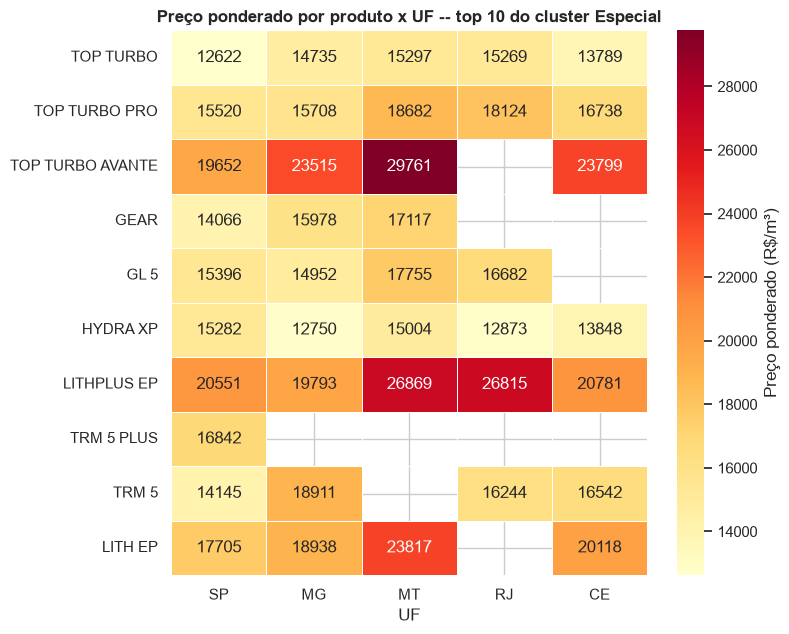

✓ preco_uf_top10_especial.png salvo


In [42]:
estado_map_pc = segmentacao.set_index('Código Cliente')['estado_cliente']
pricing_cluster['estado_cliente'] = pricing_cluster['Código Cliente'].map(estado_map_pc)
pricing_especial = pricing_cluster[pricing_cluster['cluster'] == especial_id]

top5_uf_especial = (pricing_especial.groupby('estado_cliente', observed=True)['Código Cliente']
    .nunique().sort_values(ascending=False).head(5).index)

def preco_por_uf(sub_df, produtos_idx, top_ufs, min_n=10):
    g = sub_df[sub_df['Prod - Família de Produtos'].isin(produtos_idx) & sub_df['estado_cliente'].isin(top_ufs)]
    agg = g.groupby(['Prod - Família de Produtos', 'estado_cliente'], observed=True).agg(
        volume=('volume', 'sum'), receita=('receita_liquida', 'sum'), n=('Código Cliente', 'nunique'))
    agg['preco'] = agg['receita'] / agg['volume']
    preco = agg['preco'].unstack().reindex(produtos_idx)[top_ufs]
    n = agg['n'].unstack().reindex(produtos_idx)[top_ufs]
    return preco.where(n.fillna(0) >= min_n)

preco_especial_uf = preco_por_uf(pricing_especial, top10_especial.index, top5_uf_especial)

rotulos_top5_esp = [SIGLA_UF.get(uf, uf) for uf in preco_especial_uf.columns]
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(preco_especial_uf, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            xticklabels=rotulos_top5_esp,
            cbar_kws={'label': 'Preço ponderado (R$/m³)'}, linewidths=0.5, linecolor='white')
ax.set_xticklabels(rotulos_top5_esp, rotation=0)
ax.set_title('Preço ponderado por produto x UF -- top 10 do cluster Especial', fontweight='bold')
ax.set_xlabel('UF'); ax.set_ylabel('')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'preco_uf_top10_especial.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ preco_uf_top10_especial.png salvo')


**Achado:** Mato Grosso é a UF mais cara em praticamente todo produto do top 10 do Especial onde há amostra suficiente — chegando a **R$ 29.761/m³ em TOP TURBO AVANTE** e **R$ 26.869/m³ em LITHPLUS EP**, bem acima do que se paga nas mesmas famílias em São Paulo ou Minas Gerais. O achado de frete/UF (seção 6) não é só um efeito de composição de cluster — ele aparece produto a produto.


### Preço por UF — comparando os 4 clusters

O mesmo recorte (preço por produto × UF), agora para os 4 clusters lado a lado, usando o top 10 *geral* (para comparar as mesmas famílias) e a mesma escala de cor em todos os painéis. Cada cluster usa suas próprias 5 UFs mais frequentes.


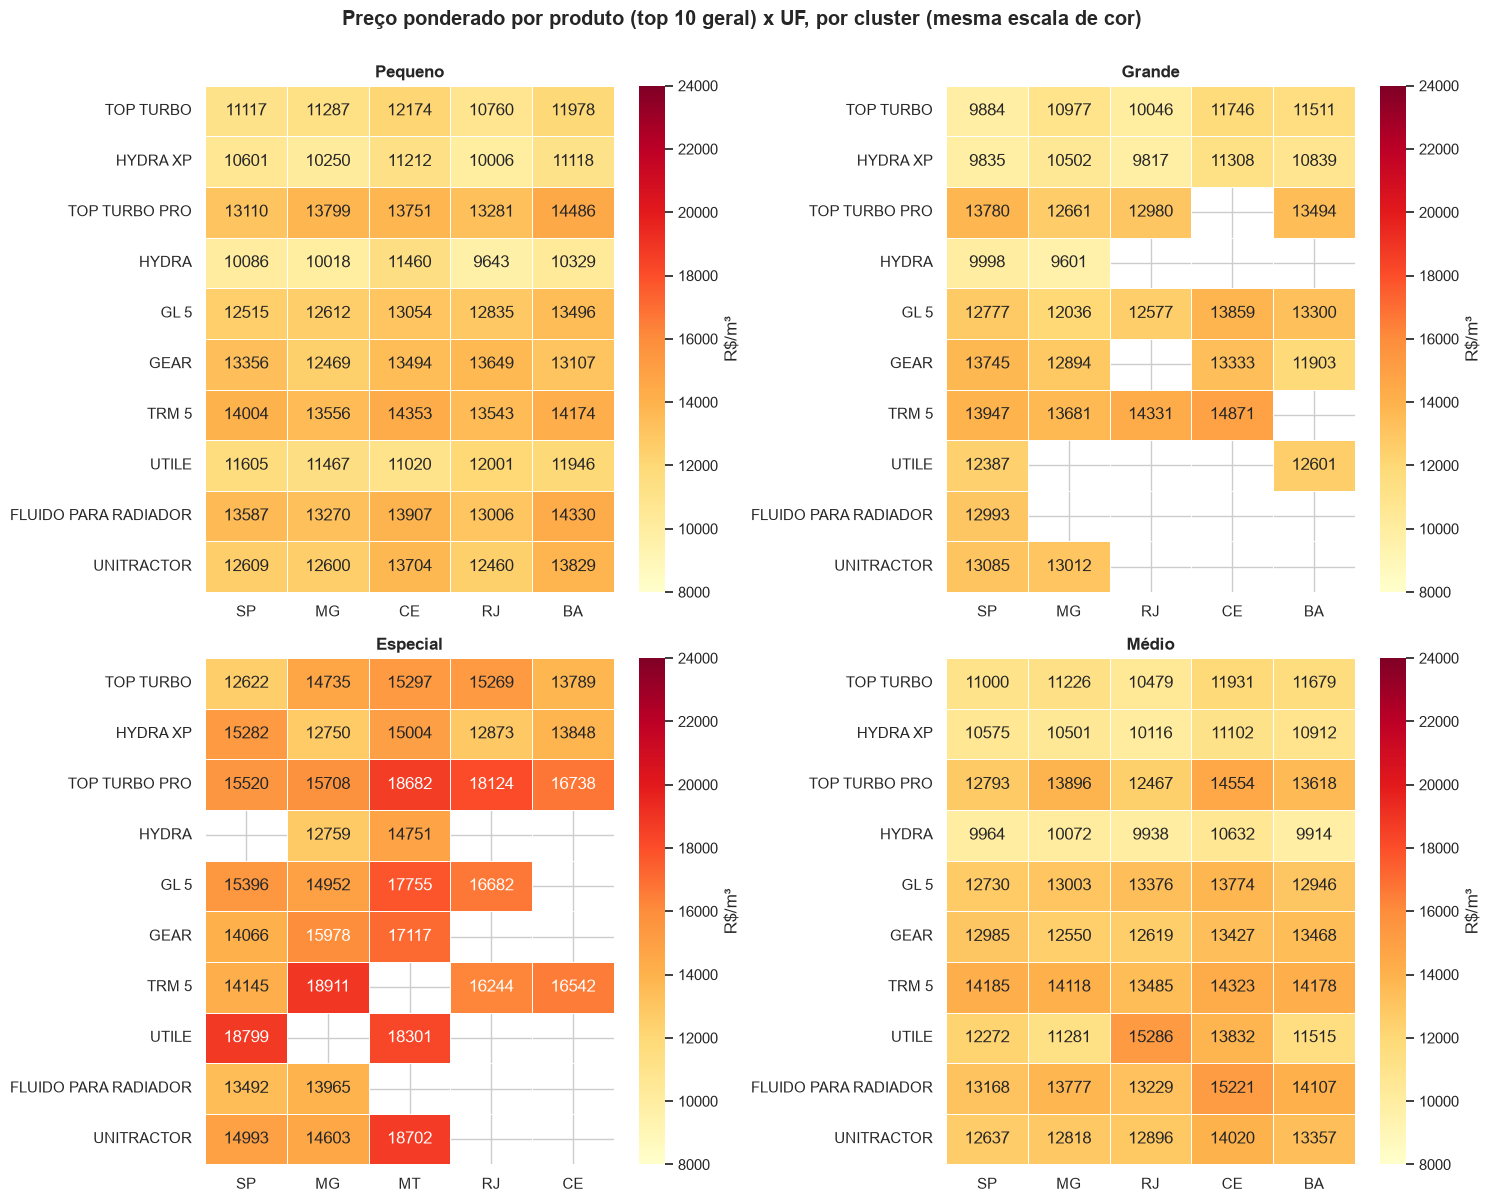

✓ preco_uf_4clusters.png salvo


In [43]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
vmin, vmax = 8000, 24000
for ax, cid in zip(axes.flat, sorted(NOMES_CLUSTER)):
    sub_cluster = pricing_cluster[pricing_cluster['cluster'] == cid]
    top5 = (sub_cluster.groupby('estado_cliente', observed=True)['Código Cliente']
            .nunique().sort_values(ascending=False).head(5).index)
    preco = preco_por_uf(sub_cluster, top10_familias_geral.index, top5)
    rotulos_top5 = [SIGLA_UF.get(uf, uf) for uf in preco.columns]
    sns.heatmap(preco, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax, vmin=vmin, vmax=vmax,
                xticklabels=rotulos_top5,
                cbar_kws={'label': 'R$/m³'}, linewidths=0.5, linecolor='white')
    ax.set_xticklabels(rotulos_top5, rotation=0)
    ax.set_title(NOMES_CLUSTER[cid], fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('')
fig.suptitle('Preço ponderado por produto (top 10 geral) x UF, por cluster (mesma escala de cor)', fontweight='bold', y=1.0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'preco_uf_4clusters.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ preco_uf_4clusters.png salvo')


**Achado:** na mesma escala de cor, o painel do Especial é visivelmente mais escuro (mais caro) que Pequeno, Grande e Médio em praticamente toda combinação produto × UF — não é um efeito de uma UF ou produto isolado, é o cluster inteiro que paga mais, em qualquer corte que se olhe.


## 9. Resumo executivo e conclusões

In [44]:
n_segmentos_finais = len(segmentos)
n_potenciais = segmentacao["cluster"].nunique() * TOP_N_FAMILIAS
top5_receita_pct = pareto.head(5)["receita_pct"].sum()
top10_clientes_pct = segmentos.sort_values("clientes_unicos", ascending=False).head(10)["clientes_unicos"].sum() / segmentos["clientes_unicos"].sum() * 100

print(f"""
{"="*78}
SEGMENTAÇÃO HÍBRIDA — RESUMO EXECUTIVO
{"="*78}

Clientes analisados: {len(segmentacao):,}
K-Means Clusters: {segmentacao["cluster"].nunique()} (modelo atual, 2.Kmeans.ipynb)
Famílias de Produtos nomeadas: {TOP_N_FAMILIAS} (top por volume, sem bucket Outras -- cobertura parcial)
Níveis de Frequência: 3

Combinações possíveis (cluster × top {TOP_N_FAMILIAS} família): {n_potenciais}
Combinações viáveis (≥{MIN_CLIENTES_CELULA} clientes cada, sem bucket Outras): {n_segmentos_finais}
Segmentos para cobrir 80% da receita: {n_para_80}
% de receita nos top 5 segmentos: {top5_receita_pct:.1f}%
% de clientes nos top 10 segmentos: {top10_clientes_pct:.1f}%

PRÓXIMOS PASSOS:
  1. Validar os clusters e os segmentos híbridos com o time comercial
  2. Usar a matriz cluster × família (preço e margem reais) como referência operacional de pricing
  3. Monitorar estabilidade dos clusters e da composição de família/frequência (rerun trimestral)
{"="*78}
""")



SEGMENTAÇÃO HÍBRIDA — RESUMO EXECUTIVO

Clientes analisados: 7,050
K-Means Clusters: 4 (modelo atual, 2.Kmeans.ipynb)
Famílias de Produtos nomeadas: 10 (top por volume, sem bucket Outras -- cobertura parcial)
Níveis de Frequência: 3

Combinações possíveis (cluster × top 10 família): 40
Combinações viáveis (≥10 clientes cada, sem bucket Outras): 40
Segmentos para cobrir 80% da receita: 16
% de receita nos top 5 segmentos: 51.6%
% de clientes nos top 10 segmentos: 60.6%

PRÓXIMOS PASSOS:
  1. Validar os clusters e os segmentos híbridos com o time comercial
  2. Usar a matriz cluster × família (preço e margem reais) como referência operacional de pricing
  3. Monitorar estabilidade dos clusters e da composição de família/frequência (rerun trimestral)



## Conclusão

Análise de segmentação híbrida concluída. Os 5 arquivos e 3 gráficos foram salvos em
`outputs/segmentacao_hibrida/`. As correções feitas em relação ao pedido original
(`teste_hibrido.txt`) estão documentadas na introdução deste notebook.